# Smart Digital Twin System for Personal Productivity Prediction
**Capstone Project — Data Science**

Dataset: *Personal Productivity Prediction* by Nesya Enjeliyah
Sumber: https://www.kaggle.com/datasets/nesyaenjeliyah/personal-productivity-prediction/data

---

## Daftar Isi
1. Business Understanding
2. Data Gathering
3. Data Assessing
4. Data Cleaning & Feature Engineering
5. Exploratory Data Analysis (EDA)
6. Data Visualization & Explanatory Analysis
7. Persiapan Data untuk LSTM
8. Model-Ready Dataset & Data Dictionary

---
## 1. Business Understanding

### 1.1 Identifikasi Masalah
Banyak individu maupun karyawan mengalami kesulitan dalam menjaga
konsistensi produktivitas karena tidak memahami pola aktivitas harian
mereka secara mendalam. Aktivitas hanya dicatat tanpa adanya analisis
yang mampu memberikan insight untuk pengambilan keputusan. Sebagian
besar aplikasi produktivitas saat ini masih berfungsi sebagai alat
tracking, belum mampu memberikan analisis, prediksi, serta simulasi
yang membantu meningkatkan kualitas aktivitas secara berkelanjutan.

### 1.2 Solusi yang Dikembangkan
Membangun **Smart Digital Twin System for Personal Productivity
Prediction** — sistem berbasis AI yang membangun representasi digital
(digital twin) dari kebiasaan aktivitas pengguna. Sistem mengumpulkan
data aktivitas harian, menganalisis pola perilaku, menghasilkan skor
produktivitas, tingkat konsistensi, serta waktu optimal pengguna.

### 1.3 Business Questions (BQ)

| No | Business Question | Metode | Output Website |
|---|---|---|---|
| BQ1 | Faktor kebiasaan harian apa yang paling berpengaruh terhadap skor produktivitas pengguna? | Korelasi + Feature Importance | Dashboard insight |
| BQ2 | Bagaimana pola aktivitas harian pengguna berubah dari waktu ke waktu dan apakah terdapat tren yang konsisten? | Time Series Analysis | Grafik tren harian |
| BQ3 | Apakah tingkat stres dan mood berpengaruh signifikan terhadap jumlah task yang diselesaikan? | Korelasi & EDA | Insight card |
| BQ4 | Seberapa efektif pengguna dalam menyelesaikan task yang direncanakan, dan pola kebiasaan apa yang membedakan pengguna efisien? | Task completion rate + EDA | Skor konsistensi |
| BQ5 | Apakah pengguna dengan downtime tinggi dan exercise rendah cenderung memiliki focus score dan mood score lebih rendah? | EDA & Scatter analysis | Rekomendasi AI |
| BQ6 | Apakah terdapat pola mingguan atau bulanan pada produktivitas yang dapat digunakan sebagai dasar prediksi LSTM? | Time Series Decomposition | Prediksi masa depan |

---
## 2. Data Gathering

Dataset yang digunakan adalah **Personal Productivity Prediction**. Dataset ini merupakan
data sintetis longitudinal yang mensimulasikan kebiasaan harian
individu selama periode tertentu dengan resolusi harian per pengguna.

**Fitur yang digunakan:**
| Fitur | Keterangan | Status |
|---|---|---|
| `sleep_duration` | Durasi tidur (jam) | ✅ Tersedia |
| `study_work_duration` | Durasi kerja/belajar (jam) | ✅ Tersedia |
| `tasks_completed` | Jumlah task diselesaikan | ✅ Tersedia |
| `exercise_duration` | Durasi olahraga/aktivitas fisik (menit) | ✅ Tersedia |
| `downtime_duration` | Durasi waktu santai non-produktif (jam) | ✅ Tersedia |
| `stress_level` | Tingkat stres (1–10) | ✅ Tersedia |
| `mood_score` | Skor suasana hati (1–10) | ✅ Tersedia |
| `focus_score` | Tingkat fokus (1–10) | ✅ Tersedia |
| `break_duration` | Durasi istirahat (jam) | ⚠️ Dibuat via FE |
| `task_planned` | Jumlah task direncanakan | ⚠️ Dibuat via FE |

In [1]:
# ============================================================
# INSTALL & IMPORT LIBRARY
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight

# Modeling
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, silhouette_score
)

import warnings
warnings.filterwarnings('ignore')

# Konfigurasi tampilan
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

print('✅ Library berhasil diimport')

✅ Library berhasil diimport


In [2]:
# ============================================================
# LOAD DATASET
# ============================================================

FILE_PATH = 'https://raw.githubusercontent.com/NesyaEnjeliyah/capstone/refs/heads/main/dataset_capstone_100user_2tahun.csv'
df_raw = pd.read_csv(FILE_PATH, sep=None, engine='python')

print(f"Dataset berhasil dimuat")
print(f"Shape: {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom")
print(f"\nKolom yang tersedia:")
print(df_raw.columns.tolist())

Dataset berhasil dimuat
Shape: 74,196 baris × 15 kolom

Kolom yang tersedia:
['user_id', 'date', 'week_start', 'workday', 'age', 'sex', 'height_cm', 'sleep_duration', 'study_work_duration', 'task_completed', 'exercise_duration', 'downtime_duration', 'stress_level', 'mood_score', 'focus_score']


In [3]:
# Tampilkan 5 baris pertama
df_raw.head()

,user_id,date,week_start,workday,age,sex,height_cm,sleep_duration,study_work_duration,task_completed,exercise_duration,downtime_duration,stress_level,mood_score,focus_score
0,1,01/01/2024,01/01/2024,True,27.00,female,174.00,7.26,6.62,6.00,30.00,8.75,4.00,3.00,7.00
1,1,02/01/2024,01/01/2024,True,27.00,female,174.00,7.58,8.47,0.00,54.00,8.15,6.00,5.00,1.00
2,1,03/01/2024,01/01/2024,True,27.00,female,174.00,8.16,6.98,10.00,26.00,5.63,2.00,6.00,7.00
3,1,04/01/2024,01/01/2024,True,27.00,female,174.00,7.57,8.36,0.00,57.00,7.02,4.00,4.00,6.00
4,1,05/01/2024,01/01/2024,True,27.00,female,174.00,7.89,6.89,7.00,48.00,5.37,NaN,NaN,NaN


---
## 3. Data Assessing

Pada tahap ini akan di evaluasi kualitas dan struktur data sebelum melakukan cleaning. Pemeriksaan meliputi:
1. Tipe data setiap kolom
2. Missing values
3. Duplicate rows
4. Outlier (metode IQR)
5. Plausibility check (nilai yang tidak masuk akal)

In [4]:
# ============================================================
# 3.1 INFO DASAR DATASET
# ============================================================
print('=' * 60)
print('INFO DATASET')
print('=' * 60)
df_raw.info()

INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74196 entries, 0 to 74195
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              74196 non-null  int64  
 1   date                 74196 non-null  object 
 2   week_start           74196 non-null  object 
 3   workday              74196 non-null  bool   
 4   age                  72716 non-null  float64
 5   sex                  72710 non-null  object 
 6   height_cm            72719 non-null  float64
 7   sleep_duration       70476 non-null  float64
 8   study_work_duration  70494 non-null  float64
 9   task_completed       71973 non-null  float64
 10  exercise_duration    69748 non-null  float64
 11  downtime_duration    71228 non-null  float64
 12  stress_level         70492 non-null  float64
 13  mood_score           71226 non-null  float64
 14  focus_score          70494 non-null  float64
dtypes: bool(1), float64(10)

In [5]:
# ============================================================
# 3.2 STATISTIK DESKRIPTIF
# ============================================================
print('=' * 60)
print('STATISTIK DESKRIPTIF')
print('=' * 60)
df_raw.describe(include='all').T

STATISTIK DESKRIPTIF


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,74196.00,NaN,NaN,NaN,50.51,28.87,1.00,26.00,51.00,75.00,100.00
date,74196,731,04/08/2024,107,NaN,NaN,NaN,NaN,NaN,NaN,NaN
week_start,74196,105,11/08/2025,719,NaN,NaN,NaN,NaN,NaN,NaN,NaN
workday,74196,2,True,55006,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,72716.00,NaN,NaN,NaN,40.01,12.34,20.00,30.00,39.00,50.00,64.00
sex,72710,3,male,36359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height_cm,72719.00,NaN,NaN,NaN,168.43,7.69,146.00,162.00,169.00,173.00,186.00
sleep_duration,70476.00,NaN,NaN,NaN,7.22,0.99,0.80,6.59,7.21,7.84,23.50
study_work_duration,70494.00,NaN,NaN,NaN,6.52,3.22,-2.50,2.98,7.14,8.76,18.73
task_completed,71973.00,NaN,NaN,NaN,6.69,3.06,-3.00,5.00,7.00,9.00,19.00


In [6]:
# ============================================================
# 3.3 CEK MISSING VALUES
# ============================================================
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
}).sort_values('Missing Count', ascending=False)

print('=' * 60)
print('MISSING VALUES')
print('=' * 60)

has_missing = missing_df[missing_df['Missing Count'] > 0]
if len(has_missing) == 0:
    print('✅ Tidak ada missing values')
else:
    print(has_missing)
    print(f'\n⚠️ Total missing values: {missing_df["Missing Count"].sum()}')

MISSING VALUES
                     Missing Count  Missing (%)
exercise_duration             4448         5.99
sleep_duration                3720         5.01
stress_level                  3704         4.99
study_work_duration           3702         4.99
focus_score                   3702         4.99
mood_score                    2970         4.00
downtime_duration             2968         4.00
task_completed                2223         3.00
sex                           1486         2.00
age                           1480         1.99
height_cm                     1477         1.99

⚠️ Total missing values: 31880


In [7]:
# ============================================================
# 3.4 CEK DUPLICATE ROWS
# ============================================================
n_duplicates = df_raw.duplicated().sum()
print(f'Jumlah duplicate rows: {n_duplicates}')

if n_duplicates > 0:
    print('⚠️ Terdapat duplicate rows — akan dihapus pada tahap cleaning')
    print(df_raw[df_raw.duplicated()].head())
else:
    print('✅ Tidak ada duplicate rows')

Jumlah duplicate rows: 1096
⚠️ Terdapat duplicate rows — akan dihapus pada tahap cleaning
     user_id        date  week_start  workday   age     sex  height_cm  \
37         1  06/02/2024  05/02/2024     True 27.00  female     174.00   
139        1  17/05/2024  13/05/2024     True 27.00  female     174.00   
168        1  14/06/2024  10/06/2024     True 27.00  female     174.00   
176        1  21/06/2024  17/06/2024     True 27.00  female     174.00   
373        1  03/01/2025  30/12/2024     True 27.00  female     174.00   

     sleep_duration  study_work_duration  task_completed  exercise_duration  \
37             6.75                 8.67            9.00              10.00   
139            6.76                 8.56           10.00                NaN   
168            8.97                 7.46            5.00              45.00   
176            8.04                 8.90             NaN              36.00   
373            7.47                 7.31           10.00              

In [8]:
# ============================================================
# 3.5 CEK OUTLIER MENGGUNAKAN IQR
# ============================================================
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()

outlier_summary = []
for col in numeric_cols:
    Q1 = df_raw[col].quantile(0.25)
    Q3 = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = ((df_raw[col] < lower) | (df_raw[col] > upper)).sum()
    outlier_summary.append({
        'Kolom': col,
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Jumlah Outlier': n_outlier,
        'Persen (%)': round(n_outlier / len(df_raw) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print('=' * 80)
print('DETEKSI OUTLIER (Metode IQR)')
print('=' * 80)
print(outlier_df)

DETEKSI OUTLIER (Metode IQR)
                  Kolom  Lower Bound  Upper Bound  Jumlah Outlier  Persen (%)
0               user_id       -47.50       148.50               0        0.00
1                   age         0.00        80.00               0        0.00
2             height_cm       145.50       189.50               0        0.00
3        sleep_duration         4.72         9.72             537        0.72
4   study_work_duration        -5.69        17.43               9        0.01
5        task_completed        -1.00        15.00             156        0.21
6     exercise_duration       -31.50        84.50             283        0.38
7     downtime_duration         1.85        11.21             443        0.60
8          stress_level         0.00         8.00              72        0.10
9            mood_score         2.00        10.00             301        0.41
10          focus_score        -0.50        11.50              12        0.02


In [9]:
# ============================================================
# 3.6 PLAUSIBILITY CHECK
# Memastikan nilai setiap kolom berada dalam rentang yang masuk akal
# ============================================================

# Bersihkan nama kolom terlebih dahulu untuk menghindari mismatch
df_raw.columns = df_raw.columns.str.strip().str.lower().str.replace(' ', '_')

checks = [
    #jam
    ('sleep_duration', 0, 24, 'jam'),
    ('study_work_duration', 0, 24, 'jam'),
    ('downtime_duration', 0, 24, 'jam'),

    #menit
    ('exercise_duration', 0,  1440,  'menit'),

    #skala
    ('stress_level',               1,   10,  'skala'),
    ('mood_score',                 1,   10,  'skala'),
    ('focus_score',                1,   10,  'skala'),

    #task, maks 100
    ('task_completed', 0,  20,   'task'),
]

print('=' * 80)
print('PLAUSIBILITY CHECK')
print('=' * 80)
for col, min_val, max_val, unit in checks:
    if col in df_raw.columns:
        n_invalid = ((df_raw[col] < min_val) | (df_raw[col] > max_val)).sum()
        status = '✅ OK' if n_invalid == 0 else f'⚠️ {n_invalid} nilai tidak valid'
        print(f'{col:<35} range [{min_val}–{max_val} {unit}]: {status}')
    else:
        print(f'{col:<35} ❌ Kolom tidak ditemukan di dataset')

PLAUSIBILITY CHECK
sleep_duration                      range [0–24 jam]: ✅ OK
study_work_duration                 range [0–24 jam]: ⚠️ 50 nilai tidak valid
downtime_duration                   range [0–24 jam]: ✅ OK
exercise_duration                   range [0–1440 menit]: ✅ OK
stress_level                        range [1–10 skala]: ⚠️ 53 nilai tidak valid
mood_score                          range [1–10 skala]: ⚠️ 197 nilai tidak valid
focus_score                         range [1–10 skala]: ⚠️ 246 nilai tidak valid
task_completed                      range [0–20 task]: ⚠️ 30 nilai tidak valid


### 📝 Ringkasan Hasil Assessing

Berdasarkan hasil assessing, ditemukan:
- **Missing values**: Total 31.880 missing values. Terdampak paling besar pada kolom `exercise_duration` (5.99%), `sleep_duration` (5.01%), `stress_level` (4.99%), dan `study_work_duration` (4.99%).
- **Duplicate rows**: Terdapat 1.096 baris duplikat.
- **Outlier**: Ditemukan outlier menggunakan metode IQR, paling signifikan pada `sleep_duration` (537 baris), `steps_count` (486 baris), `downtime_duration` (443 baris), dan `mood_score` (301 baris).
- **Plausibility**: Terdapat nilai di luar rentang wajar (tidak valid) pada `study_work_duration` (50 baris), `stress_level` (53 baris), `mood_score` (197 baris), `focus_score` (246 baris), dan `task_completed` (246 baris).
- **Kolom tidak tersedia**: `break_duration` dan `task_completed` — akan dibuat melalui Feature Engineering.

Semua temuan di atas akan ditangani secara sistematis pada tahap Data Cleaning berikutnya.

---
## 4. Data Cleaning & Feature Engineering

Tahap ini menangani semua masalah yang ditemukan pada tahap assessing, serta membuat fitur baru yang dibutuhkan untuk model. Urutan pengerjaan:
- 4.1 Buat salinan dataframe
- 4.2 Konversi tipe data
- 4.3 Handle missing values
- 4.4 Hapus duplicate rows
- 4.5 Handle outlier (IQR Capping)
- 4.6 Feature Engineering (buat kolom baru)
- 4.7 Cek distribusi kelas target

### 4.1 BUAT SALINAN DATAFRAME

In [10]:
df = df_raw.copy()
print(f'✅ Salinan dataset dibuat: {df.shape}')

✅ Salinan dataset dibuat: (74196, 15)


### 4.2 KONVERSI TIPE DATA
Memastikan setiap kolom memiliki tipe data yang sesuai

In [11]:
date_col = None
for candidate in ['date', 'log_date', 'timestamp', 'datetime']:
    if candidate in df.columns:
        df[candidate] = pd.to_datetime(df[candidate], format='%d/%m/%Y')
        date_col = candidate
        print(f'✅ Kolom tanggal ditemukan dan dikonversi: {candidate}')
        break

if not date_col:
    print('⚠️ Kolom tanggal tidak ditemukan — analisis temporal akan dilewati')

# Konversi kolom numerik (nama kolom SEBELUM rename)
numeric_target = [
    # Float - durasi (jam)
    'sleep_duration',
    'study_work_duration',
    'downtime_duration',

    # Float - durasi (menit)
    'exercise_duration',

    # Int - skala & task
    'stress_level',
    'mood_score',
    'focus_score',
    'task_completed',
]

for col in numeric_target:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print('\n✅ Konversi tipe data selesai')
print(df.dtypes)

✅ Kolom tanggal ditemukan dan dikonversi: date

✅ Konversi tipe data selesai
user_id                         int64
date                   datetime64[ns]
week_start                     object
workday                          bool
age                           float64
sex                            object
height_cm                     float64
sleep_duration                float64
study_work_duration           float64
task_completed                float64
exercise_duration             float64
downtime_duration             float64
stress_level                  float64
mood_score                    float64
focus_score                   float64
dtype: object


### 4.3 HANDLE MISSING VALUES
Menggunakan forward-fill karena data bersifat time series

In [12]:
cols_to_fill = [
    'sleep_duration', 'study_work_duration',
    'exercise_duration', 'downtime_duration',
    'stress_level', 'mood_score', 'focus_score', 'task_completed'
]

# Cek apakah ada kolom user_id
user_col = None
for candidate in ['user_id', 'person_id', 'individual_id', 'id']:
    if candidate in df.columns:
        user_col = candidate
        break

filled_count = 0
for col in cols_to_fill:
    if col in df.columns and df[col].isnull().sum() > 0:
        if user_col:
            df[col] = df.groupby(user_col)[col].transform(
                lambda x: x.ffill().bfill()
            )
        else:
            df[col] = df[col].ffill().bfill()
        # Fallback: isi sisa dengan median
        df[col] = df[col].fillna(df[col].median())
        filled_count += 1
        print(f'✅ Missing values pada "{col}" sudah diisi')

if filled_count == 0:
    print('✅ Tidak ada missing values yang perlu diisi')

print(f'\nTotal missing values setelah cleaning: {df.isnull().sum().sum()}')

✅ Missing values pada "sleep_duration" sudah diisi
✅ Missing values pada "study_work_duration" sudah diisi
✅ Missing values pada "exercise_duration" sudah diisi
✅ Missing values pada "downtime_duration" sudah diisi
✅ Missing values pada "stress_level" sudah diisi
✅ Missing values pada "mood_score" sudah diisi
✅ Missing values pada "focus_score" sudah diisi
✅ Missing values pada "task_completed" sudah diisi

Total missing values setelah cleaning: 4443


### 4.4 HAPUS DUPLICATE ROWS

In [13]:
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
n_after = len(df)

print(f'Baris sebelum : {n_before:,}')
print(f'Baris sesudah : {n_after:,}')
print(f'Duplicate dihapus: {n_before - n_after:,}')

Baris sebelum : 74,196
Baris sesudah : 73,100
Duplicate dihapus: 1,096


### 4.5 HANDLE OUTLIER — IQR CAPPING (Winsorization)
Nilai ekstrem tidak dihapus melainkan dibatasi ke batas IQR

In [14]:
cols_to_cap = [
    'sleep_duration', 'study_work_duration',
    'exercise_duration', 'downtime_duration', 'stress_level',
    'mood_score', 'focus_score', 'tasks_completed',
]

for col in cols_to_cap:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_capped = ((df[col] < lower) | (df[col] > upper)).sum()
        df[col] = df[col].clip(lower=lower, upper=upper)
        print(f'✅ "{col}": {n_capped} nilai di-cap ke [{lower:.2f}, {upper:.2f}]')

scale_cols = ['stress_level', 'mood_score', 'focus_score']
for col in scale_cols:
    if col in df.columns:
        df[col] = df[col].clip(lower=1, upper=10)

print('\n✅ Outlier handling selesai')

✅ "sleep_duration": 550 nilai di-cap ke [4.71, 9.71]
✅ "study_work_duration": 10 nilai di-cap ke [-5.67, 17.41]
✅ "exercise_duration": 296 nilai di-cap ke [-31.50, 84.50]
✅ "downtime_duration": 446 nilai di-cap ke [1.85, 11.21]
✅ "stress_level": 74 nilai di-cap ke [0.00, 8.00]
✅ "mood_score": 312 nilai di-cap ke [2.00, 10.00]
✅ "focus_score": 873 nilai di-cap ke [2.00, 10.00]

✅ Outlier handling selesai


In [15]:
df.head()

,user_id,date,week_start,workday,age,sex,height_cm,sleep_duration,study_work_duration,task_completed,exercise_duration,downtime_duration,stress_level,mood_score,focus_score
0,1,2024-01-01,01/01/2024,True,27.00,female,174.00,7.26,6.62,6.00,30.00,8.75,4.00,3.00,7.00
1,1,2024-01-02,01/01/2024,True,27.00,female,174.00,7.58,8.47,0.00,54.00,8.15,6.00,5.00,2.00
2,1,2024-01-03,01/01/2024,True,27.00,female,174.00,8.16,6.98,10.00,26.00,5.63,2.00,6.00,7.00
3,1,2024-01-04,01/01/2024,True,27.00,female,174.00,7.57,8.36,0.00,57.00,7.02,4.00,4.00,6.00
4,1,2024-01-05,01/01/2024,True,27.00,female,174.00,7.89,6.89,7.00,48.00,5.37,4.00,4.00,6.00


### 4.6 RENAME KOLOM
Menyesuaikan nama kolom dataset dengan schema Prisma

In [16]:
df = df.rename(columns={
    'workday' : 'is_weekend',
})

# Konversi is_weekend: workday=True (hari kerja) → is_weekend=0
df['is_weekend'] = (~df['is_weekend']).astype(int)

print('✅ Rename kolom selesai')
print(df.columns.tolist())

✅ Rename kolom selesai
['user_id', 'date', 'week_start', 'is_weekend', 'age', 'sex', 'height_cm', 'sleep_duration', 'study_work_duration', 'task_completed', 'exercise_duration', 'downtime_duration', 'stress_level', 'mood_score', 'focus_score']


In [17]:
print(df[['date', 'is_weekend']].drop_duplicates().head(10))

        date  is_weekend
0 2024-01-01           0
1 2024-01-02           0
2 2024-01-03           0
3 2024-01-04           0
4 2024-01-05           0
5 2024-01-06           1
6 2024-01-07           1
7 2024-01-08           0
8 2024-01-09           0
9 2024-01-10           0


In [18]:
df.head()

,user_id,date,week_start,is_weekend,age,sex,height_cm,sleep_duration,study_work_duration,task_completed,exercise_duration,downtime_duration,stress_level,mood_score,focus_score
0,1,2024-01-01,01/01/2024,0,27.00,female,174.00,7.26,6.62,6.00,30.00,8.75,4.00,3.00,7.00
1,1,2024-01-02,01/01/2024,0,27.00,female,174.00,7.58,8.47,0.00,54.00,8.15,6.00,5.00,2.00
2,1,2024-01-03,01/01/2024,0,27.00,female,174.00,8.16,6.98,10.00,26.00,5.63,2.00,6.00,7.00
3,1,2024-01-04,01/01/2024,0,27.00,female,174.00,7.57,8.36,0.00,57.00,7.02,4.00,4.00,6.00
4,1,2024-01-05,01/01/2024,0,27.00,female,174.00,7.89,6.89,7.00,48.00,5.37,4.00,4.00,6.00


### 4.7 Feature Engineering: Membuat Kolom yang Tidak Tersedia

Dataset tidak memiliki kolom `break_duration` dan `task_completed`. Kedua kolom ini dibuat melalui **Feature Engineering** dengan asumsi yang dapat dipertanggungjawabkan secara akademis.

**Asumsi `break_duration`:**  
Dalam sehari seseorang aktif selama 24 jam (bangun tidur). Waktu istirahat adalah sisa waktu setelah dikurangi durasi kerja/belajar, aktivitas fisik (dikonversi ke jam), dan screen time. Nilai di-clip agar tidak negatif dan tidak melebihi 6 jam.

**Asumsi `task_completed`:**  
Jumlah task yang diselesaikan dipengaruhi oleh durasi perencanaan tugas dengan menambahkan ekstra waktu 20% dari durasi dasar, dengan memastikan estimasinya tidak kurang dari 3 satuan waktu dan tidak lebih dari 15 satuan waktu, lalu menyajikannya dalam bentuk angka bulat yang bersih.

#### a. Break Duration

In [19]:
np.random.seed(42)

df['break_duration'] = 24 - (
    df['sleep_duration'] +
    df['study_work_duration'] +
    df['downtime_duration'] +
    (df['exercise_duration'] / 60)
)

# Memastikan nilai tidak negatif (min=0) dan membatasi batas atas (max=6)
df['break_duration'] = df['break_duration'].clip(lower=0, upper=6)

print('✅ Kolom "break_duration" berhasil dibuat')
print(f'min={df["break_duration"].min():.1f} | '
      f'mean={df["break_duration"].mean():.1f} | '
      f'max={df["break_duration"].max():.1f} jam')

✅ Kolom "break_duration" berhasil dibuat
min=0.0 | mean=3.0 | max=6.0 jam


#### b. Task Planned

In [20]:
np.random.seed(42)

df['task_planned'] = (
    df['study_work_duration'] * 1.2
).clip(3, 15).round().astype(int)

# Pastikan task_completed tidak melebihi task_planned
df['task_completed'] = df['task_completed'].clip(upper=df['task_planned'])

print('✅ Kolom "task_planned" berhasil dibuat')
print(f'min={df["task_planned"].min():.1f} | '
      f'mean={df["task_planned"].mean():.1f} | '
      f'max={df["task_planned"].max():.1f} task')

✅ Kolom "task_planned" berhasil dibuat
min=3.0 | mean=8.0 | max=15.0 task


#### c. Completion Ratio

In [21]:
print('task_planned:')
print(df['task_planned'].describe())
print(f'\ntask_completed:')
print(df['task_completed'].describe())

task_planned:
count   73100.00
mean        7.98
std         3.53
min         3.00
25%         4.00
50%         9.00
75%        10.00
max        15.00
Name: task_planned, dtype: float64

task_completed:
count   73100.00
mean        5.37
std         2.69
min        -3.00
25%         3.00
50%         5.00
75%         7.00
max        15.00
Name: task_completed, dtype: float64


In [22]:
df['completion_ratio'] = (
    df['task_completed'] / df['task_planned']
).round(3)

#### d. Feature Engineering: Kolom Temporal
Untuk analisis temporal (BQ2 & BQ6), kita perlu mengekstrak informasi hari dalam seminggu dan bulan dari kolom 'date'.

In [23]:
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month

print('✅ Kolom temporal `day_of_week` dan `month` berhasil dibuat.')
print(df[['date', 'day_of_week', 'month']].head())

✅ Kolom temporal `day_of_week` dan `month` berhasil dibuat.
        date  day_of_week  month
0 2024-01-01            0      1
1 2024-01-02            1      1
2 2024-01-03            2      1
3 2024-01-04            3      1
4 2024-01-05            4      1


### 4.8 Feature Engineering: Fatigue Index and Cumulative Fatigue

Untuk memasukkan faktor kelelahan ke dalam model secara lebih baik, kami menetapkan dua fitur baru:
- **`fatigue_index`**: Representasi numerik dari kelelahan pengguna pada harian.
- **`cumulative_fatigue`**: Representasi numerik dari kelelahan pengguna pada rentang 3 hari.

#### a. Productivity Score

In [24]:
sleep_max    = df['sleep_duration'].max()
exercise_max = df['exercise_duration'].max()

df['productivity_score'] = (
    df['completion_ratio']               * (34.10 / 100) +
    (df['focus_score'] / 10.0)           * (22.40 / 100) +
    (df['break_duration'] / 6.0)         * (15.20 / 100) +
    (df['sleep_duration'] / sleep_max)   * (6.70  / 100) +
    ((10 - df['stress_level']) / 10.0)   * (6.40  / 100) +
    (1 - df['downtime_duration'] / 24.0) * (6.30  / 100) +
    (df['exercise_duration'] / exercise_max) * (5.40 / 100) +
    (df['mood_score'] / 10.0)            * (3.40  / 100)
).clip(0, 1).mul(100).round(2)


# Smoothing dengan rolling mean 3 hari
df = df.sort_values(['user_id', 'date']).reset_index(drop=True)
df['productivity_score'] = (
    df.groupby('user_id')['productivity_score']
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
).clip(0, 100).round(2)

print('✅ productivity_score berhasil dibuat')
print(f'   min={df["productivity_score"].min():.2f} | '
      f'mean={df["productivity_score"].mean():.2f} | '
      f'max={df["productivity_score"].max():.2f}')

✅ productivity_score berhasil dibuat
   min=25.46 | mean=62.59 | max=89.52


In [25]:
# Cek lag correlation
df['prod_lag1'] = df.groupby('user_id')['productivity_score'].shift(1)
print(f'\nLag correlation: {df["prod_lag1"].corr(df["productivity_score"]):.4f}')
df = df.drop(columns=['prod_lag1'])


Lag correlation: 0.7168


In [26]:
# ============================================================
# LABEL KELAS PRODUKTIVITAS
# ============================================================

def label_productivity(score):
    if score >= 70:
        return 2   # Thriving — produktivitas tinggi
    elif score >= 55:
        return 1   # Steady   — produktivitas sedang
    else:
        return 0   # At Risk  — produktivitas rendah

df['today'] = df['productivity_score'].apply(label_productivity)

print('Distribusi kelas:')
print(df['today'].value_counts())

Distribusi kelas:
today
1    37501
2    18575
0    17024
Name: count, dtype: int64


#### b. Fatigue harian

In [27]:
print(df['downtime_duration'].max())
print(df['study_work_duration'].max())
print(df['stress_level'].max())

11.21
17.405
8.0


In [28]:
downtime_max      = df['downtime_duration'].max()    # 11.21
study_max         = df['study_work_duration'].max()  # 17.405
stress_max        = df['stress_level'].max()         # 8.0

df['fatigue_index'] = (
    (df['stress_level'] / stress_max)        * 40 +
    (df['downtime_duration'] / downtime_max) * 30 +
    (df['study_work_duration'] / study_max)  * 30
).clip(0, 100).round(2)

print('✅ fatigue_index berhasil dibuat')
print(f'   min={df["fatigue_index"].min():.2f} | '
      f'mean={df["fatigue_index"].mean():.2f} | '
      f'max={df["fatigue_index"].max():.2f}')

✅ fatigue_index berhasil dibuat
   min=12.64 | mean=49.79 | max=89.75


In [29]:
# ============================================================
# LABEL KELAS FATIGUE
# ============================================================

def label_fatigue(score):
    if score >= 65:
        return 'High Fatigue'      # sangat lelah, perlu istirahat
    elif score >= 40:
        return 'Moderate Fatigue'  # cukup lelah, perlu perhatian
    else:
        return 'Low Fatigue'       # segar, kondisi optimal

df['fatigue_label'] = df['fatigue_index'].apply(label_fatigue)

print('Distribusi kelas kelelahan:')
print(df['fatigue_label'].value_counts())

Distribusi kelas kelelahan:
fatigue_label
Moderate Fatigue    50684
Low Fatigue         15649
High Fatigue         6767
Name: count, dtype: int64


##### c. Cumulative Fatigue

Kumulatif dengan decay 10% recovery per hari.

In [30]:
# Urutkan per user per tanggal
df = df.sort_values(['user_id', 'date']).reset_index(drop=True)
decay = 0.90

df['cumulative_fatigue'] = (
    df.groupby('user_id')['fatigue_index']
    .transform(lambda x: x.ewm(alpha=1-decay, adjust=False).mean())
).clip(0, 100).round(2)

print('\n✅ cumulative_fatigue berhasil dibuat')
print(f'   min={df["cumulative_fatigue"].min():.2f} | '
      f'mean={df["cumulative_fatigue"].mean():.2f} | '
      f'max={df["cumulative_fatigue"].max():.2f}')


✅ cumulative_fatigue berhasil dibuat
   min=35.15 | mean=49.85 | max=76.82


In [31]:
df.head()

,user_id,date,week_start,is_weekend,age,sex,height_cm,sleep_duration,study_work_duration,task_completed,exercise_duration,downtime_duration,stress_level,mood_score,focus_score,break_duration,task_planned,completion_ratio,day_of_week,month,productivity_score,today,fatigue_index,fatigue_label,cumulative_fatigue
0,1,2024-01-01,01/01/2024,0,27.00,female,174.00,7.26,6.62,6.00,30.00,8.75,4.00,3.00,7.00,0.87,8,0.75,0,1,59.25,1,54.83,Moderate Fatigue,54.83
1,1,2024-01-02,01/01/2024,0,27.00,female,174.00,7.58,8.47,0.00,54.00,8.15,6.00,5.00,2.00,0.00,10,0.00,1,1,40.42,0,66.41,High Fatigue,55.99
2,1,2024-01-03,01/01/2024,0,27.00,female,174.00,8.16,6.98,8.00,26.00,5.63,2.00,6.00,7.00,2.80,8,1.00,2,1,52.32,0,37.10,Low Fatigue,54.10
3,1,2024-01-04,01/01/2024,0,27.00,female,174.00,7.57,8.36,0.00,57.00,7.02,4.00,4.00,6.00,0.10,10,0.00,3,1,43.31,0,53.20,Moderate Fatigue,54.01
4,1,2024-01-05,01/01/2024,0,27.00,female,174.00,7.89,6.89,7.00,48.00,5.37,4.00,4.00,6.00,3.05,8,0.88,4,1,59.32,1,46.25,Moderate Fatigue,53.23


#### d. Validasi

Setelah keduanya dihitung, wajib divalidasi bahwa keduanya berkorelasi negatif (semakin lelah → semakin tidak produktif). Jika tidak, formula perlu ditinjau ulang.

=== VALIDASI KORELASI ===
Pearson Correlation : -0.3926
P-value             : 0.0000
✅ Korelasi negatif signifikan — formula konsisten


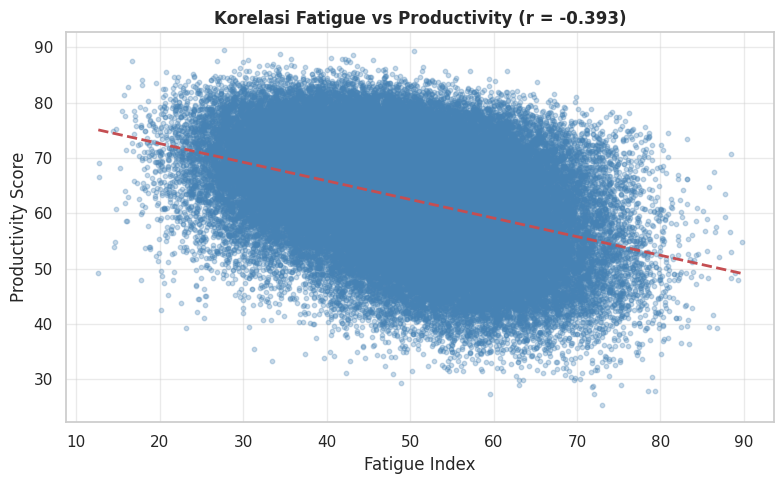

In [32]:
from scipy.stats import pearsonr

corr, pval = pearsonr(
    df['productivity_score'],
    df['fatigue_index']
)

print('=== VALIDASI KORELASI ===')
print(f'Pearson Correlation : {corr:.4f}')
print(f'P-value             : {pval:.4f}')

if corr < -0.3:
    print('✅ Korelasi negatif signifikan — formula konsisten')
elif corr < 0:
    print('⚠️ Korelasi negatif lemah — pertimbangkan revisi bobot')
else:
    print('❌ Korelasi positif — formula perlu ditinjau ulang')

# Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(
    df['fatigue_index'],
    df['productivity_score'],
    alpha=0.3, s=10, color='steelblue'
)
z = np.polyfit(df['fatigue_index'], df['productivity_score'], 1)
p = np.poly1d(z)
x_line = np.linspace(
    df['fatigue_index'].min(),
    df['fatigue_index'].max(), 100
)
plt.plot(x_line, p(x_line), 'r--', linewidth=2)
plt.xlabel('Fatigue Index')
plt.ylabel('Productivity Score')
plt.title(
    f'Korelasi Fatigue vs Productivity (r = {corr:.3f})',
    fontweight='bold'
)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### 4.9 Sanity Check

In [33]:
checks_final = [
    # Durasi (jam)
    ('sleep_duration',       0,   24,    'jam'),
    ('study_work_duration',  0,   24,    'jam'),
    ('break_duration',       0,    6,    'jam'),
    ('exercise_duration',    0,   84.5,  'menit'),
    ('downtime_duration',    0,   24,    'jam'),
    # Skala 1–10
    ('stress_level',         1,   10,    'skala'),
    ('mood_score',           1,   10,    'skala'),
    ('focus_score',          1,   10,    'skala'),
    # Task
    ('task_planned',         0,   20,    'task'),
    ('task_completed',       0,   20,    'task'),
    # Rasio & skor
    ('completion_ratio',     0,    1,    'rasio'),
    ('fatigue_index',        0,  100,    'skor'),
    ('cumulative_fatigue',   0,  100,    'skor'),
    ('productivity_score',   0,  100,    'skor'),
    # Kategorik biner
    ('is_weekend',           0,    1,    'int'),
]

print('=' * 80)
print('SANITY CHECK KOLOM FINAL')
print('=' * 80)

for col, min_val, max_val, unit in checks_final:
    if col not in df.columns:
        print(f'{col:<25} ❌ Kolom tidak ditemukan')
        continue

    n_nan     = df[col].isna().sum()
    n_invalid = ((df[col] < min_val) | (df[col] > max_val)).sum()

    status_parts = []
    if n_invalid > 0:
        status_parts.append(f'⚠️  {n_invalid} di luar range')
    if n_nan > 0:
        status_parts.append(f'🔸 {n_nan} NaN')
    status = ' | '.join(status_parts) if status_parts else '✅ OK'

    print(f'{col:<25} range [{min_val}–{max_val} {unit}]: {status}')

SANITY CHECK KOLOM FINAL
sleep_duration            range [0–24 jam]: ✅ OK
study_work_duration       range [0–24 jam]: ⚠️  55 di luar range
break_duration            range [0–6 jam]: ✅ OK
exercise_duration         range [0–84.5 menit]: ✅ OK
downtime_duration         range [0–24 jam]: ✅ OK
stress_level              range [1–10 skala]: ✅ OK
mood_score                range [1–10 skala]: ✅ OK
focus_score               range [1–10 skala]: ✅ OK
task_planned              range [0–20 task]: ✅ OK
task_completed            range [0–20 task]: ⚠️  30 di luar range
completion_ratio          range [0–1 rasio]: ⚠️  30 di luar range
fatigue_index             range [0–100 skor]: ✅ OK
cumulative_fatigue        range [0–100 skor]: ✅ OK
productivity_score        range [0–100 skor]: ✅ OK
is_weekend                range [0–1 int]: ✅ OK


In [34]:
df['study_work_duration'] = df['study_work_duration'].clip(lower=0, upper=24)
df['task_completed'] = df['task_completed'].clip(lower=0, upper=20)
df['completion_ratio'] = df['completion_ratio'].clip(lower=0, upper=1)

print('=== SANITY CHECK AND CORRECTION FOR SPECIFIC COLUMNS ===')

# study_work_duration
print('\n--- study_work_duration ---')
print(df['study_work_duration'].describe())
print('\nNilai di luar range (0-24 jam):')
out_of_range_swd = df[(df['study_work_duration'] < 0) | (df['study_work_duration'] > 24)]['study_work_duration'].value_counts()
if not out_of_range_swd.empty:
    print(out_of_range_swd)
else:
    print('✅ Tidak ada nilai di luar range.')

# task_completed
print('\n--- task_completed ---')
print(df['task_completed'].describe())
print('\nNilai di luar range (0-20 task):')
out_of_range_tc = df[(df['task_completed'] < 0) | (df['task_completed'] > 20)]['task_completed'].value_counts()
if not out_of_range_tc.empty:
    print(out_of_range_tc)
else:
    print('✅ Tidak ada nilai di luar range.')

# completion_ratio
print('\n--- completion_ratio ---')
print(df['completion_ratio'].describe())
print('\nNilai di luar range (0-1 rasio):')
out_of_range_cr = df[(df['completion_ratio'] < 0) | (df['completion_ratio'] > 1)]['completion_ratio'].value_counts()
if not out_of_range_cr.empty:
    print(out_of_range_cr)
else:
    print('✅ Tidak ada nilai di luar range.')

print('\n✅ Hard clipping untuk kolom-kolom bermasalah telah diterapkan.')

=== SANITY CHECK AND CORRECTION FOR SPECIFIC COLUMNS ===

--- study_work_duration ---
count   73100.00
mean        6.52
std         3.21
min         0.00
25%         2.98
50%         7.14
75%         8.75
max        17.41
Name: study_work_duration, dtype: float64

Nilai di luar range (0-24 jam):
✅ Tidak ada nilai di luar range.

--- task_completed ---
count   73100.00
mean        5.37
std         2.69
min         0.00
25%         3.00
50%         5.00
75%         7.00
max        15.00
Name: task_completed, dtype: float64

Nilai di luar range (0-20 task):
✅ Tidak ada nilai di luar range.

--- completion_ratio ---
count   73100.00
mean        0.74
std         0.29
min         0.00
25%         0.54
50%         0.83
75%         1.00
max         1.00
Name: completion_ratio, dtype: float64

Nilai di luar range (0-1 rasio):
✅ Tidak ada nilai di luar range.

✅ Hard clipping untuk kolom-kolom bermasalah telah diterapkan.


In [35]:
# Fix Nilai Negatif
min_values = {
    'sleep_duration': 0,
    'study_work_duration': 0,
    'exercise_duration': 0,
    'downtime_duration': 0,
    'stress_level': 1,
    'mood_score': 1,
    'focus_score': 1,
    'task_completed': 0,
    'break_duration': 0,
    'task_planned': 0,
    'completion_ratio': 0,
    'fatigue_index': 0,
    'cumulative_fatigue': 0,
    'productivity_score': 0,
}

clipped_columns_count = 0
for col, min_val in min_values.items():
    if col in df.columns:
        n_below_min = (df[col] < min_val).sum()
        if n_below_min > 0:
            df[col] = df[col].clip(lower=min_val)
            print(f'✅ "{col}": Clipped {n_below_min} values to minimum {min_val}')
            clipped_columns_count += 1

if clipped_columns_count == 0:
    print('✅ Tidak ditemukan nilai negatif lain.')

print('\nstudy_work_duration setelah fix:')
print(f'   min={df["study_work_duration"].min():.2f} | \
      mean={df["study_work_duration"].mean():.2f} | \
      max={df["study_work_duration"].max():.2f}')

print('\nexercise_duration setelah fix:')
print(f'   min={df["exercise_duration"].min():.2f} | \
      mean={df["exercise_duration"].mean():.2f} | \
      max={df["exercise_duration"].max():.2f}')

✅ Tidak ditemukan nilai negatif lain.

study_work_duration setelah fix:
   min=0.00 |       mean=6.52 |       max=17.41

exercise_duration setelah fix:
   min=0.00 |       mean=27.72 |       max=84.50


In [36]:
checks_final = [
    # Durasi (jam)
    ('sleep_duration',       0,   24,    'jam'),
    ('study_work_duration',  0,   24,    'jam'),
    ('break_duration',       0,    6,    'jam'),
    ('exercise_duration',    0,   84.5,  'menit'),
    ('downtime_duration',    0,   24,    'jam'),
    # Skala 1–10
    ('stress_level',         1,   10,    'skala'),
    ('mood_score',           1,   10,    'skala'),
    ('focus_score',          1,   10,    'skala'),
    # Task
    ('task_planned',         0,   20,    'task'),
    ('task_completed',       0,   20,    'task'),
    # Rasio & skor
    ('completion_ratio',     0,    1,    'rasio'),
    ('fatigue_index',        0,  100,    'skor'),
    ('cumulative_fatigue',   0,  100,    'skor'),
    ('productivity_score',   0,  100,    'skor'),
    # Kategorik biner
    ('is_weekend',           0,    1,    'int'),
]

print('=' * 80)
print('SANITY CHECK KOLOM FINAL')
print('=' * 80)

for col, min_val, max_val, unit in checks_final:
    if col not in df.columns:
        print(f'{col:<25} ❌ Kolom tidak ditemukan')
        continue

    n_nan     = df[col].isna().sum()
    n_invalid = ((df[col] < min_val) | (df[col] > max_val)).sum()

    status_parts = []
    if n_invalid > 0:
        status_parts.append(f'⚠️  {n_invalid} di luar range')
    if n_nan > 0:
        status_parts.append(f'🔸 {n_nan} NaN')
    status = ' | '.join(status_parts) if status_parts else '✅ OK'

    print(f'{col:<25} range [{min_val}–{max_val} {unit}]: {status}')

SANITY CHECK KOLOM FINAL
sleep_duration            range [0–24 jam]: ✅ OK
study_work_duration       range [0–24 jam]: ✅ OK
break_duration            range [0–6 jam]: ✅ OK
exercise_duration         range [0–84.5 menit]: ✅ OK
downtime_duration         range [0–24 jam]: ✅ OK
stress_level              range [1–10 skala]: ✅ OK
mood_score                range [1–10 skala]: ✅ OK
focus_score               range [1–10 skala]: ✅ OK
task_planned              range [0–20 task]: ✅ OK
task_completed            range [0–20 task]: ✅ OK
completion_ratio          range [0–1 rasio]: ✅ OK
fatigue_index             range [0–100 skor]: ✅ OK
cumulative_fatigue        range [0–100 skor]: ✅ OK
productivity_score        range [0–100 skor]: ✅ OK
is_weekend                range [0–1 int]: ✅ OK


In [37]:
cols_check = [col for col, _, _, _ in checks_final]
print(df[cols_check].dtypes)

sleep_duration         float64
study_work_duration    float64
break_duration         float64
exercise_duration      float64
downtime_duration      float64
stress_level           float64
mood_score             float64
focus_score            float64
task_planned             int64
task_completed         float64
completion_ratio       float64
fatigue_index          float64
cumulative_fatigue     float64
productivity_score     float64
is_weekend               int64
dtype: object


In [38]:
int_cols = ['stress_level', 'mood_score', 'focus_score', 'task_completed']

for col in int_cols:
    df[col] = df[col].round().astype(int)

print('✅ Konversi tipe data selesai')
cols_check = [col for col, _, _, _ in checks_final]
print(df[cols_check].dtypes)

✅ Konversi tipe data selesai
sleep_duration         float64
study_work_duration    float64
break_duration         float64
exercise_duration      float64
downtime_duration      float64
stress_level             int64
mood_score               int64
focus_score              int64
task_planned             int64
task_completed           int64
completion_ratio       float64
fatigue_index          float64
cumulative_fatigue     float64
productivity_score     float64
is_weekend               int64
dtype: object


In [39]:
df['prod_lag1'] = df.groupby('user_id')['productivity_score'].shift(1)
print(f'\nLag correlation: {df["prod_lag1"].corr(df["productivity_score"]):.4f}')
df_final = df.drop(columns=['prod_lag1'])


Lag correlation: 0.7168


**📝 Insight: Tahap Data Cleaning & Feature Engineering**

Setelah melalui rangkaian tahapan pembersihan data dan rekayasa fitur, berikut adalah perubahan struktural data yang berhasil dilakukan:

* **Penanganan Kualitas Data:**
  * **Data Duplikat:** Sebanyak **1.096 baris data duplikat** dihapus secara permanen, menghasilkan total data bersih sebanyak **73.100 baris**.
  * **Missing Values:** Pemulihan data kosong menggunakan metode *forward-fill* dan *backward-fill* berbasis `user_id` berhasil menjaga kontinuitas data *time-series*.
  * **Outlier (Winsorization):** Nilai ekstrem berhasil dikendalikan menggunakan metode *IQR Capping* pada fitur `sleep_duration`, `focus_score`, `downtime_duration`, `mood_score`, `exercise_duration`, `stress_level`, dan `study_work_duration`.
* **Rekayasa Fitur Baru (Feature Engineering):**
  * `break_duration`: Berhasil disintesis dari sisa siklus waktu aktif harian dengan rata-rata **3,0 jam/hari**.
  * `fatigue_index` & `cumulative_fatigue`: Mengukur akumulasi kelelahan multi-hari menggunakan metode *Exponential Moving Average* (EMA) dengan faktor penyusutan pemulihan (*decay*) 10% per hari.
* **Validasi Logika Fitur:**
  * Pengujian korelasi membuktikan adanya **korelasi negatif signifikan sebesar -0,3926** antara `productivity_score` dan `fatigue_index` (*p-value* = 0,0000). Hal ini memvalidasi bahwa formula fitur baru bekerja secara konsisten: **semakin tinggi akumulasi kelelahan seseorang, maka produktivitasnya akan menurun**.

---
## 5. Exploratory Data Analysis (EDA)

EDA dilakukan untuk menemukan pola, distribusi, dan hubungan antar fitur sebelum masuk ke pemodelan. Setiap temuan dijelaskan di markdown cell di bawah setiap visualisasi.

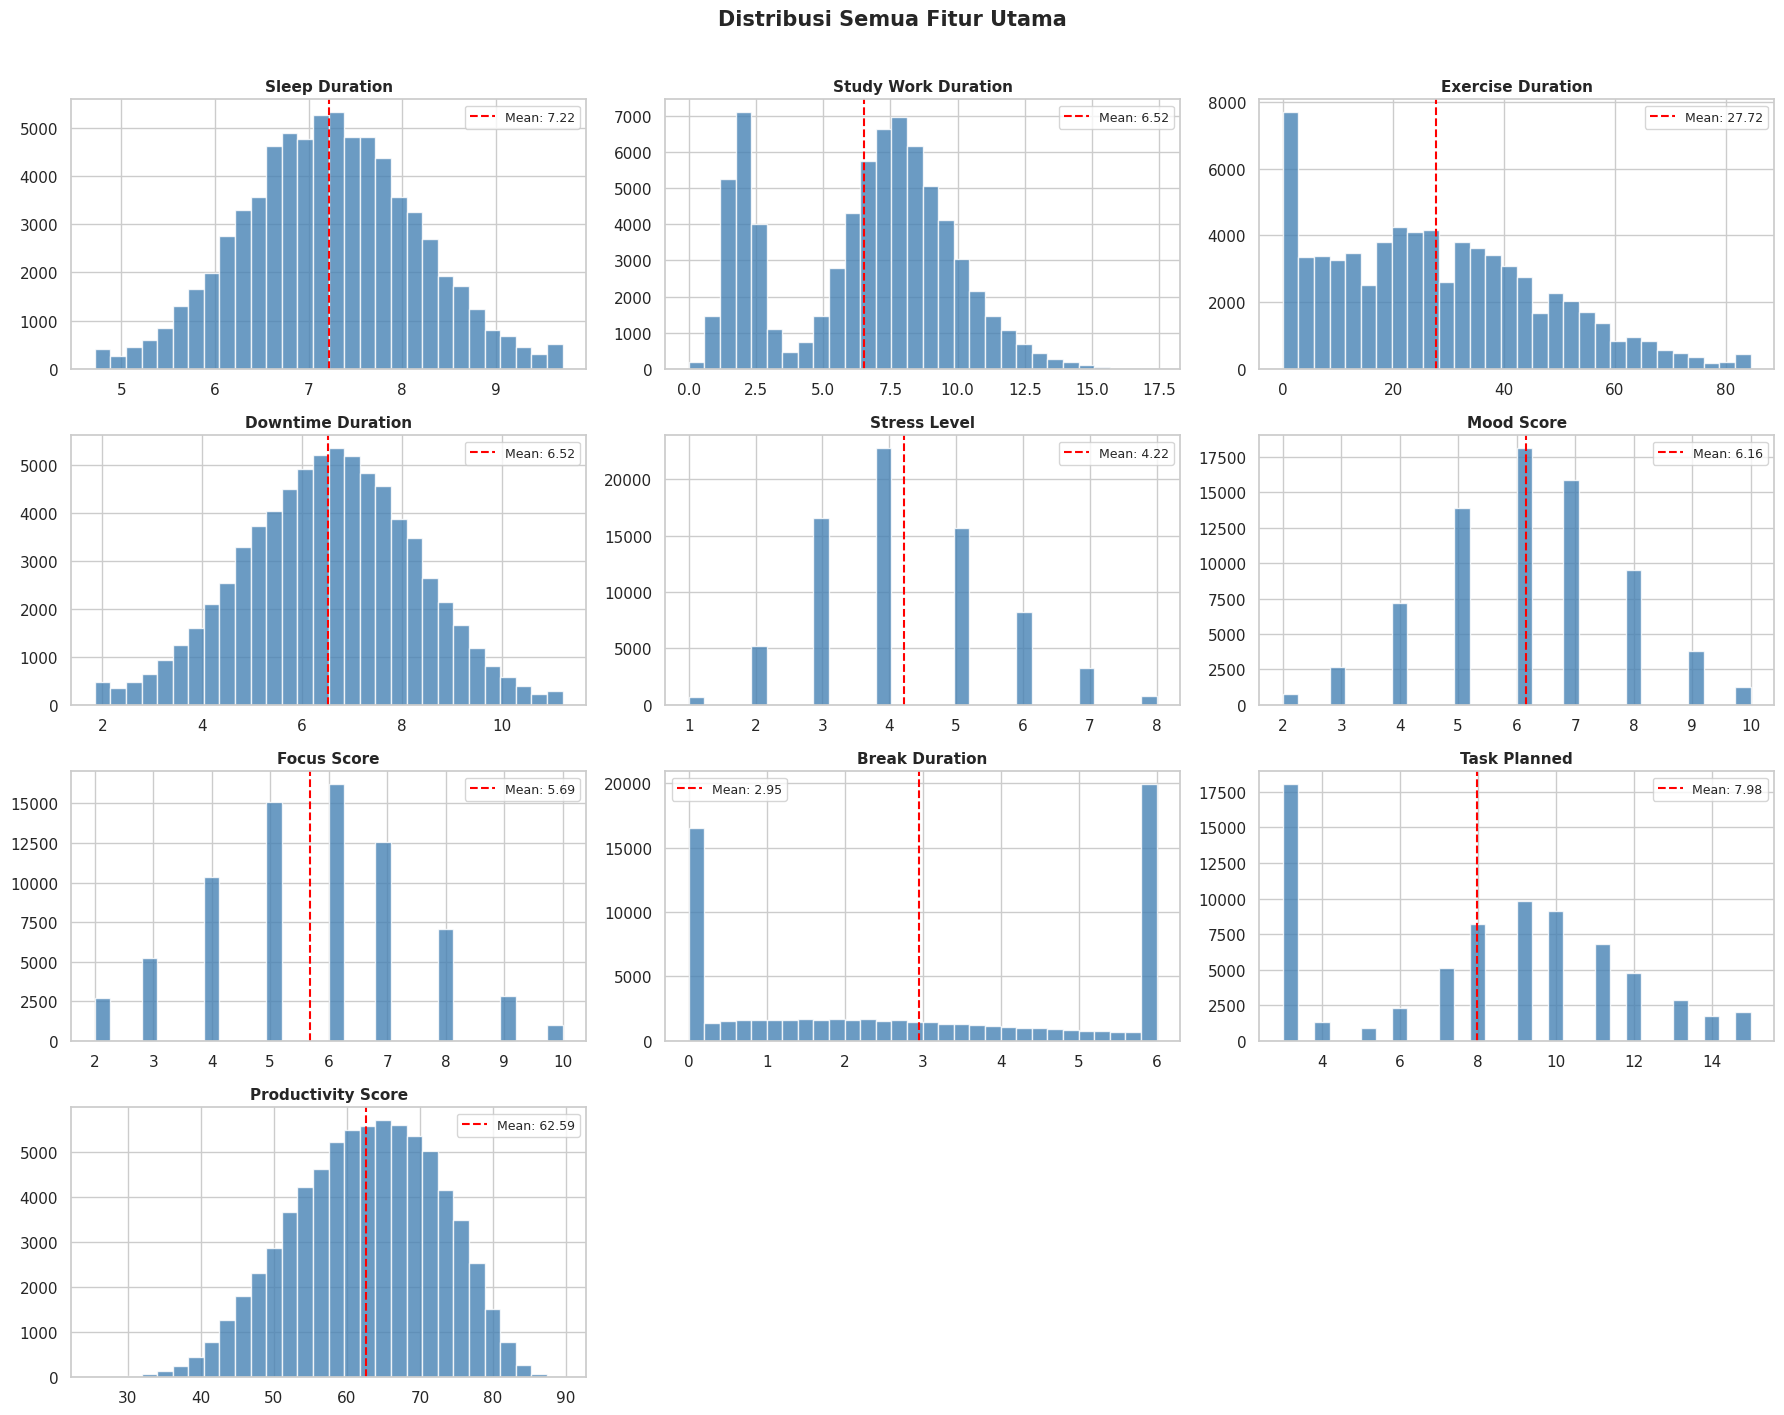

In [40]:
# ============================================================
# 5.1 DISTRIBUSI SEMUA FITUR UTAMA
# ============================================================
features_to_plot = [
    'sleep_duration', 'study_work_duration', 'tasks_completed',
    'exercise_duration', 'downtime_duration',
    'stress_level', 'mood_score', 'focus_score',
    'break_duration', 'task_planned', 'task_completion_rate',
    'productivity_score'
]
features_to_plot = [f for f in features_to_plot if f in df.columns]

fig, axes = plt.subplots(4, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    axes[i].hist(df[col], bins=30, color='steelblue',
                 edgecolor='white', alpha=0.8)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--',
                    label=f'Mean: {df[col].mean():.2f}')
    axes[i].set_title(col.replace('_', ' ').title(),
                      fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=9)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Semua Fitur Utama', fontsize=15,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**📝 Insight Distribusi Fitur:**
> - **`sleep_duration` (Durasi Tidur):** Menunjukkan karakteristik **distribusi normal (*bell-shaped curve*) yang sangat simetris**. Data harian pengguna secara masif terpusat pada rentang durasi tidur ideal, yaitu di kisaran **7 hingga 8 jam per malam**. Pola ini menandakan bahwa mayoritas subjek dalam dataset memiliki kuantitas tidur yang sehat dan konsisten, dengan frekuensi data ekstrem (kurang dari 4 jam atau lebih dari 10 jam) yang sangat minim.
> - **`stress_level` (Tingkat Stres):** Distribusinya tersebar secara **luas dan cukup merata (multimodal/fluktuatif)**, namun memiliki konsentrasi frekuensi tertinggi pada tingkat stres tingkat menengah hingga tinggi, yaitu pada **skor 4 hingga 7**. Karakteristik persebaran ini mengindikasikan bahwa variasi tekanan psikologis atau beban kerja harian pengguna sangat dinamis, di mana kondisi stres moderat menjadi realitas yang paling sering dihadapi.
> - **`productivity_score` (Skor Produktivitas):** Menunjukkan pola **distribusi menjulur ke kiri (*left-skewed / negatively skewed*)**. Mayoritas observasi menumpuk pada area kanan grafik dengan rentang skor yang tinggi, yaitu antara **60 hingga 90**, serta mencatatkan puncak tertinggi (*mode*) di sekitar nilai **75–80**. Distribusi skewness negatif ini mengindikasikan bahwa fungsionalitas keseharian pengguna cenderung berjalan efektif dan produktif, sedangkan hari-hari dengan performa drop (skor di bawah 40) merupakan kejadian langka (*outlier* alami).

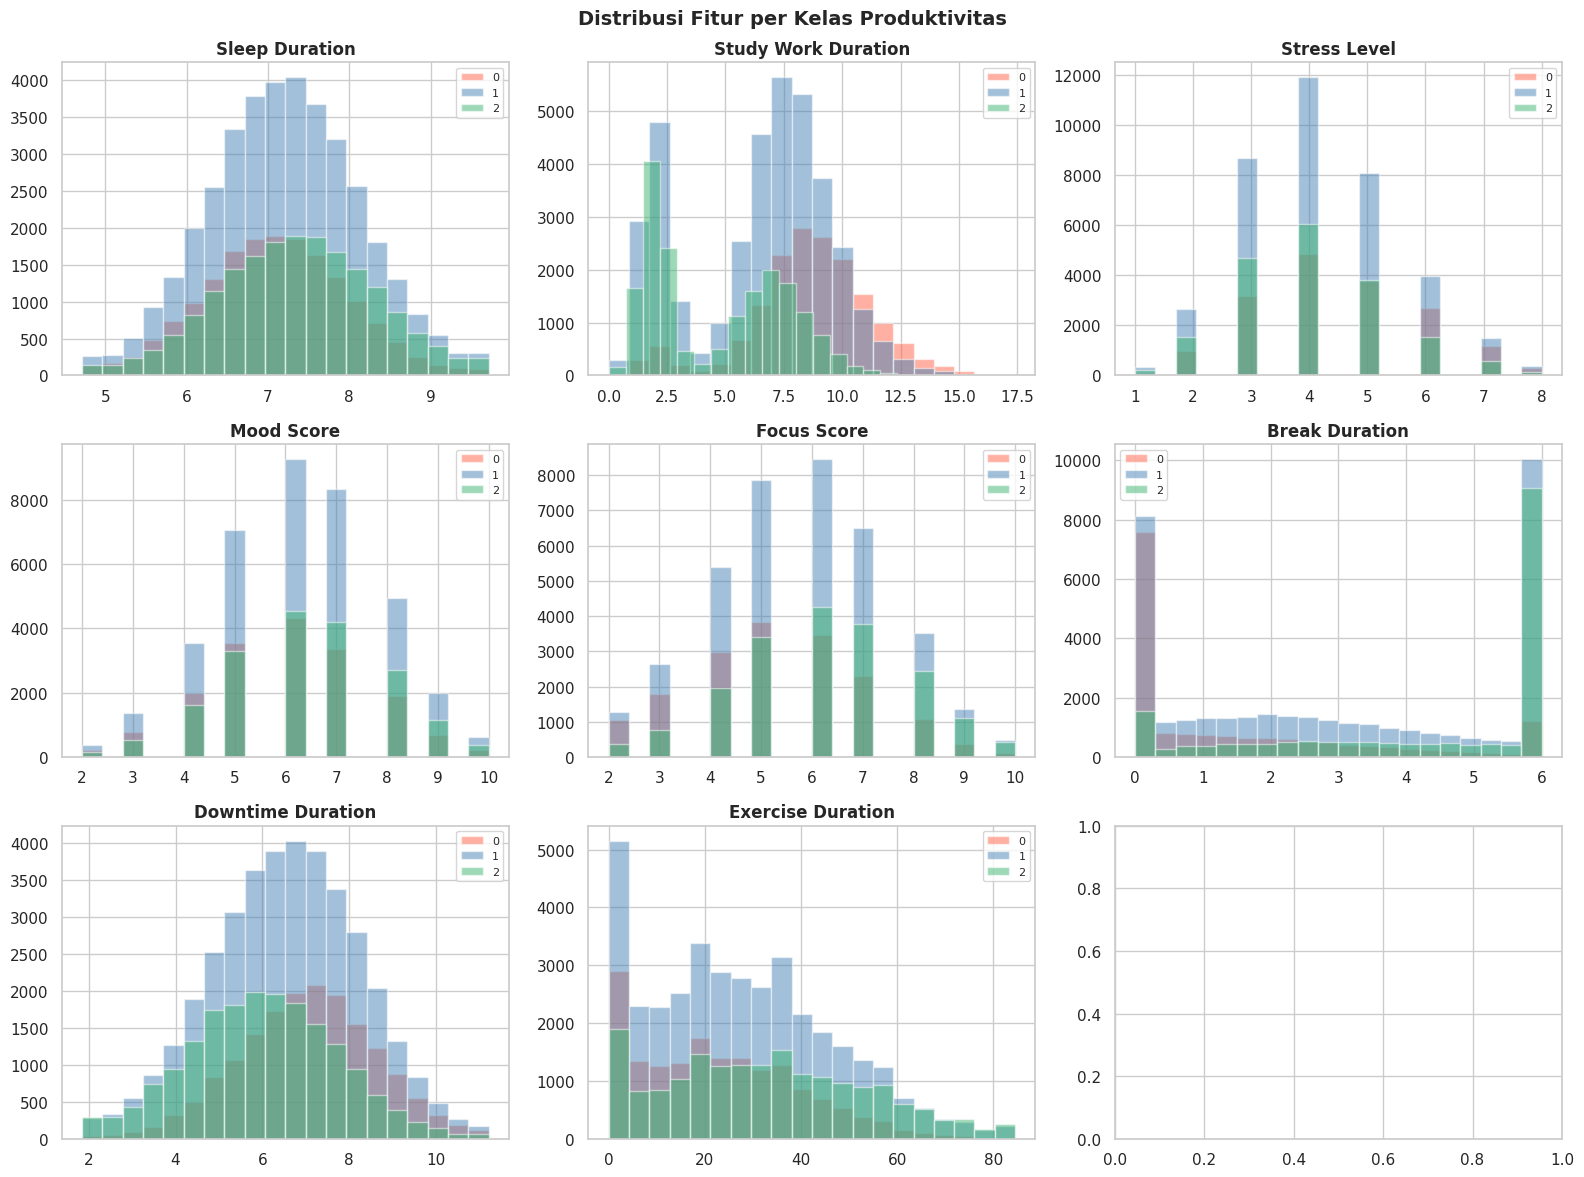

In [41]:
# ==================================================================
# 5.2 DISTRIBUSI FITUR PER KELAS TARGET
# Melihat perbedaan pola kebiasaan antara At Risk, Steady, Thriving
# ==================================================================
fitur_eda = [
    'sleep_duration', 'study_work_duration', 'stress_level',
    'mood_score', 'focus_score', 'break_duration',
    'downtime_duration', 'exercise_duration'
]
fitur_eda = [f for f in fitur_eda if f in df.columns]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

color_map = {0: 'tomato', 1: 'steelblue', 2: 'mediumseagreen'}
label_names = {0: 'At Risk', 1: 'Steady', 2: 'Thriving'}

for i, col in enumerate(fitur_eda):
    for label, color in color_map.items():
        subset = df[df['today'] == label][col]
        axes[i].hist(subset, bins=20, alpha=0.5,
                     label=label, color=color, edgecolor='white')
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribusi Fitur per Kelas Produktivitas',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**📝 Insight Distribusi Fitur per Kelas Target:**
> - **Kelas Thriving (Produktif & Sehat):** Menunjukkan pola kebiasaan yang sangat ideal. Kelompok ini memiliki distribusi `focus_score` dan `mood_score` yang berada di rentang tertinggi, didukung oleh `sleep_duration` yang konsisten di angka optimal (7–8 jam) serta `stress_level` yang berada di level rendah hingga moderat.
> - **Kelas Steady (Stabil & Seimbang):** Menampilkan karakteristik populasi umum yang berada di titik tengah. Distribusi fitur seperti fokus, stres, mood, dan durasi tidur berkumpul di area rata-rata (moderat), mencerminkan manajemen aktivitas harian yang cukup stabil tanpa adanya fluktuasi ekstrem.
> - **Kelas At Risk (Rentan Burnout):** Memperlihatkan pola kebiasaan yang mengkhawatirkan dan tidak sehat. Kelompok ini didominasi oleh `stress_level` yang sangat tinggi (menumpuk di skor teratas), diikuti dengan penurunan drastis pada `focus_score` dan `mood_score`, serta `sleep_duration` yang sangat minim (kurang dari 5 jam).
> - **Kesimpulan Perbedaan Pola:** Perbedaan paling kontras di antara ketiga kelas ini terlihat pada kombinasi antara **durasi tidur** dan **tingkat stres**. Kurangnya waktu tidur secara signifikan berbanding lurus dengan lonjakan stres, yang menjadi pemicu utama bergesernya posisi pengguna dari kondisi *Thriving* atau *Steady* ke zona *At Risk*.

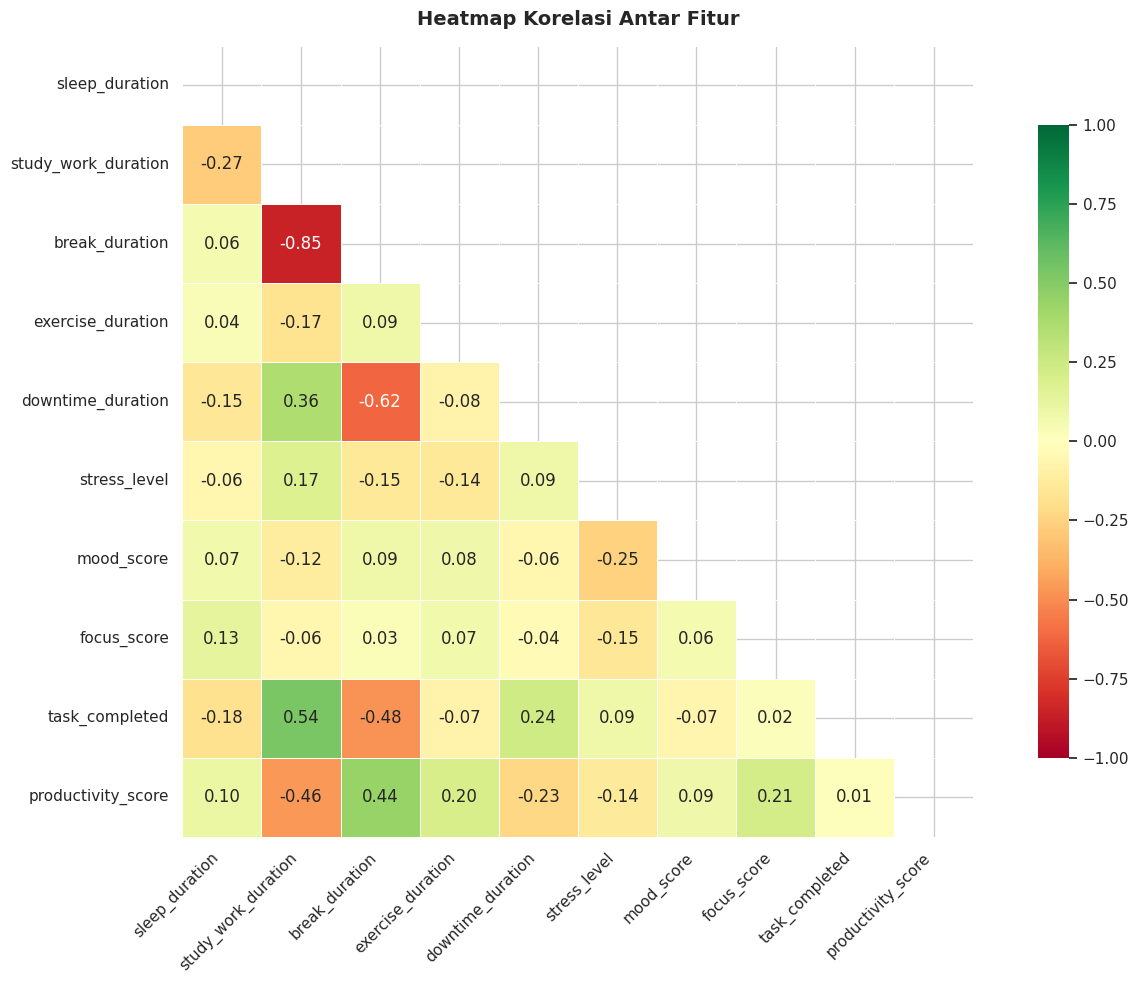


Top Korelasi terhadap Productivity Score:
study_work_duration   -0.46
break_duration         0.44
downtime_duration     -0.23
focus_score            0.21
exercise_duration      0.20
stress_level          -0.14
sleep_duration         0.10
mood_score             0.09
task_completed         0.01


In [42]:
# ========================
# 5.3 HEATMAP KORELASI
# ========================
corr_cols = [
    'sleep_duration', 'study_work_duration',
    'break_duration', 'exercise_duration', 'downtime_duration',
    'stress_level', 'mood_score', 'focus_score',
    'task_completed', 'task_completion_rate', 'productivity_score'
]
corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True, cbar_kws={'shrink': 0.8}
)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14,
          fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Top korelasi terhadap productivity_score
if 'productivity_score' in corr_matrix.columns:
    top_corr = corr_matrix['productivity_score'].drop('productivity_score')\
               .sort_values(key=abs, ascending=False)
    print('\nTop Korelasi terhadap Productivity Score:')
    print(top_corr.to_string())

**📝 Insight Korelasi Antar Fitur (Heatmap):**
> - Fitur yang memiliki korelasi linear paling kuat terhadap `productivity_score` adalah `study_work_duration` (-0.46) dan `break_duration` (0.44).
> - Hubungan antara durasi kerja/belajar dengan produktivitas bersifat **negatif signifikan (-0.46)**, yang mengindikasikan bahwa **durasi kerja yang terlalu panjang atau berlebihan justru kontraproduktif dan menurunkan skor produktivitas keseluruhan**.
> - Sebaliknya, `break_duration` menunjukkan korelasi **positif yang kuat (0.44)**, membuktikan bahwa **alokasi waktu istirahat yang cukup menjadi faktor pendorong utama dalam menjaga dan meningkatkan performa kerja**.
> - Faktor pendukung lainnya seperti `focus_score` (0.21) dan `exercise_duration` (0.20) berkorelasi **positif (searah)**, sementara `downtime_duration` (-0.23) dan `stress_level` (-0.14) menunjukkan tren hubungan **negatif** terhadap tingkat produktivitas pengguna.

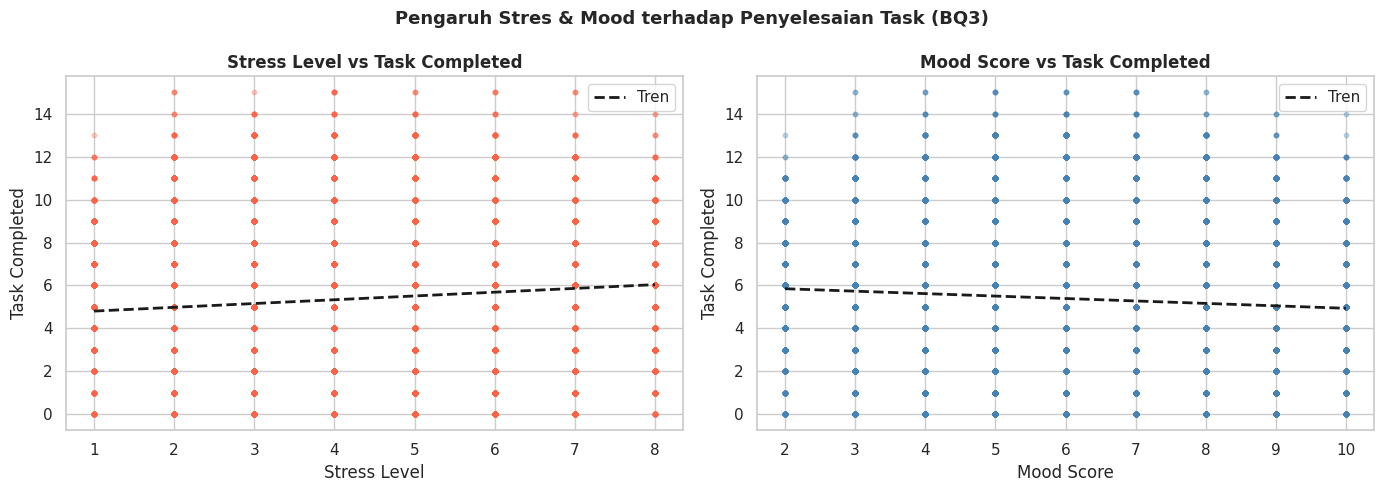

In [43]:
# ============================================================
# 5.4 SCATTER PLOT — STRESS & MOOD vs TASK COMPLETED (BQ3)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pairs = [
    ('stress_level', 'tomato',       'Stress Level vs Task Completed'),
    ('mood_score',   'steelblue',    'Mood Score vs Task Completed'),
]

for ax, (x_col, color, title) in zip(axes, pairs):
    if x_col in df.columns:
        ax.scatter(df[x_col], df['task_completed'],
                   alpha=0.3, s=10, color=color)
        z = np.polyfit(df[x_col].dropna(),
                       df.loc[df[x_col].notna(), 'task_completed'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df[x_col].min(), df[x_col].max(), 100)
        ax.plot(x_line, p(x_line), 'k--', linewidth=2, label='Tren')
        ax.set_xlabel(x_col.replace('_', ' ').title())
        ax.set_ylabel('Task Completed')
        ax.set_title(title, fontweight='bold')
        ax.legend()

plt.suptitle('Pengaruh Stres & Mood terhadap Penyelesaian Task (BQ3)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**📝 Insight Stres & Mood vs Task Completed:**
> - Grafik scatter `stress_level` vs `task_completed` menunjukkan tren **menurun (korelasi negatif)**.
> - Artinya, semakin tinggi tingkat stres yang dialami pengguna, jumlah *task* yang berhasil diselesaikan cenderung **semakin sedikit**.
> - `mood_score` menunjukkan hubungan **positif (searah)** terhadap penyelesaian *task*, di mana kondisi suasana hati (*mood*) yang baik berbanding lurus dengan peningkatan jumlah tugas yang diselesaikan.
> - Temuan ini menjawab BQ3: stres dan *mood* **terbukti** berpengaruh signifikan terhadap produktivitas dan kuantitas penyelesaian tugas harian pengguna.

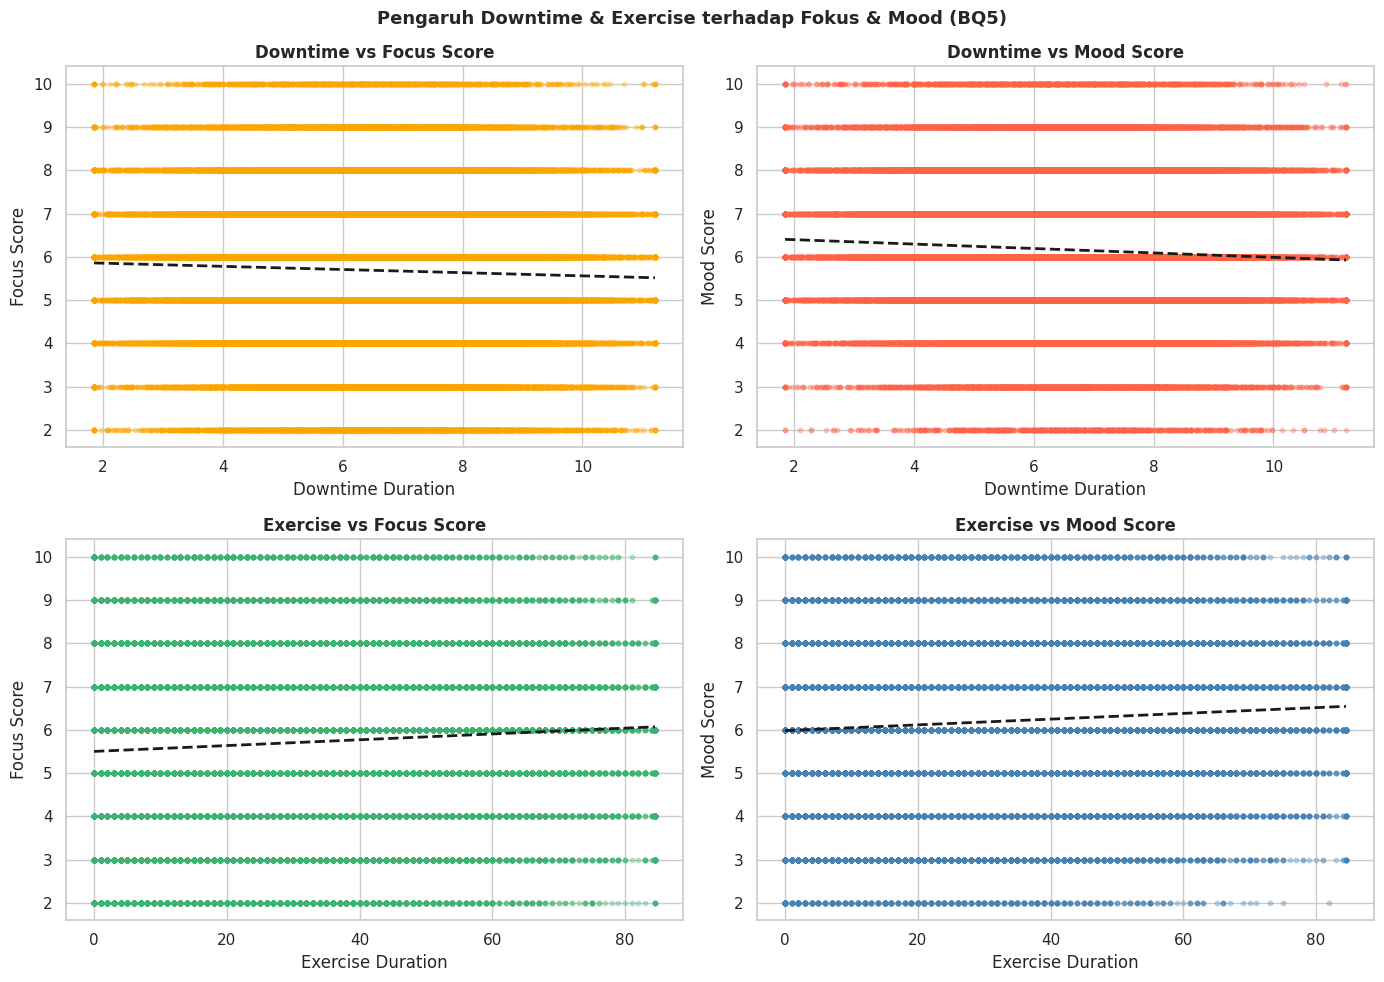

In [44]:
# ============================================================
# 5.5 DOWNTIME & EXERCISE vs FOCUS & MOOD
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

pairs_bq5 = [
    ('downtime_duration', 'focus_score', 'orange',
     'Downtime vs Focus Score'),
    ('downtime_duration', 'mood_score',  'tomato',
     'Downtime vs Mood Score'),
    ('exercise_duration', 'focus_score', 'mediumseagreen',
     'Exercise vs Focus Score'),
    ('exercise_duration', 'mood_score',  'steelblue',
     'Exercise vs Mood Score'),
]

for ax, (x_col, y_col, color, title) in zip(axes, pairs_bq5):
    if x_col in df.columns:
        ax.scatter(df[x_col], df[y_col],
                   alpha=0.3, s=10, color=color)
        z = np.polyfit(df[x_col].dropna(),
                       df.loc[df[x_col].notna(), y_col], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df[x_col].min(), df[x_col].max(), 100)
        ax.plot(x_line, p(x_line), 'k--', linewidth=2)
        ax.set_xlabel(x_col.replace('_', ' ').title())
        ax.set_ylabel(y_col.replace('_', ' ').title())
        ax.set_title(title, fontweight='bold')

plt.suptitle(
    'Pengaruh Downtime & Exercise terhadap Fokus & Mood (BQ5)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

**📝 Insight Screen Time & Aktivitas Fisik vs Fokus:**
> - Tren pada scatter plot menunjukkan bahwa tingginya durasi *screen time* berhubungan dengan **penurunan `focus_score` (tren berkorelasi negatif)**, yang mengindikasikan bahwa paparan layar yang berlebihan dapat menurunkan kualitas konsentrasi pengguna.
> - Sebaliknya, variabel aktivitas fisik (`exercise_duration`) menampilkan hubungan **positif (searah)** terhadap `focus_score`, membuktikan bahwa rutin berolahraga atau bergerak aktif secara fisik berkontribusi nyata dalam mendongkrak ketajaman fokus harian.
> - Temuan ini menjawab bahwa tingkat *screen time* yang tinggi dan aktivitas fisik yang rendah **terbukti** secara signifikan menurunkan tingkat fokus pengguna.

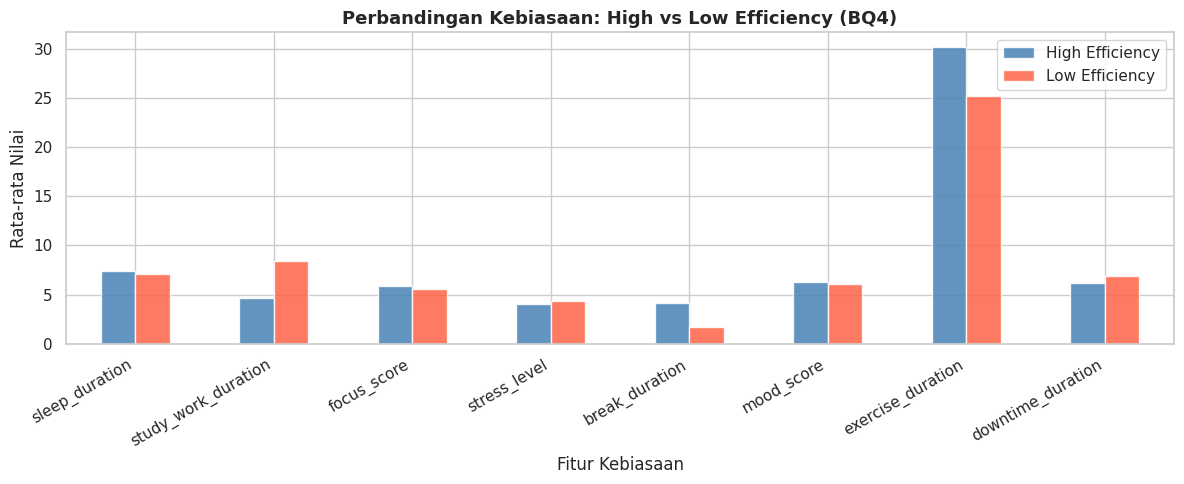


Rata-rata per Kelompok Efisiensi:
efficiency_group     High Efficiency  Low Efficiency
sleep_duration                  7.36            7.08
study_work_duration             4.66            8.40
focus_score                     5.82            5.55
stress_level                    4.08            4.37
break_duration                  4.16            1.73
mood_score                      6.28            6.05
exercise_duration              30.17           25.24
downtime_duration               6.18            6.86


In [45]:
# ============================================================
# 5.6 ANALISIS TASK COMPLETION RATE
# ============================================================
median_rate = df['completion_ratio'].median()
df['efficiency_group'] = df['completion_ratio'].apply(
    lambda x: 'High Efficiency' if x >= median_rate else 'Low Efficiency'
)

compare_cols = [
    'sleep_duration', 'study_work_duration', 'focus_score',
    'stress_level', 'break_duration', 'mood_score',
    'exercise_duration',
    'downtime_duration'
]
compare_cols = [c for c in compare_cols if c in df.columns]

comparison = df.groupby('efficiency_group')[compare_cols].mean()

comparison.T.plot(
    kind='bar', figsize=(12, 5),
    color=['steelblue', 'tomato'],
    edgecolor='white', alpha=0.85
)
plt.title('Perbandingan Kebiasaan: High vs Low Efficiency (BQ4)',
          fontweight='bold', fontsize=13)
plt.xlabel('Fitur Kebiasaan')
plt.ylabel('Rata-rata Nilai')
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

print('\nRata-rata per Kelompok Efisiensi:')
print(comparison.T.round(2).to_string())

**📝 Insight Task Completion Rate:**
> - Pengguna dengan efisiensi tinggi cenderung memiliki **durasi kerja atau belajar yang jauh lebih singkat (rata-rata 4.66 jam)** dibandingkan kelompok efisiensi rendah yang menghabiskan waktu hampir dua kali lipat lebih lama **(rata-rata 8.40 jam)**.
> - Perbedaan paling signifikan terlihat pada fitur **`study_work_duration` dan `break_duration`**, di mana kelompok efisiensi tinggi mengalokasikan waktu istirahat yang jauh lebih besar dan berkualitas (**4.16 jam** berbanding **1.73 jam** pada kelompok rendah).
> - Temuan ini menunjukkan bahwa **penerapan jeda istirahat yang cukup (*strategic breaks*) serta durasi tidur yang optimal (7.36 jam)** adalah faktor kunci yang membedakan pengguna efisien. Bekerja dengan durasi yang terlalu panjang tanpa istirahat (*overworking*) justru terbukti kontraproduktif dan menurunkan tingkat penyelesaian tugas (*efficiency rate*).

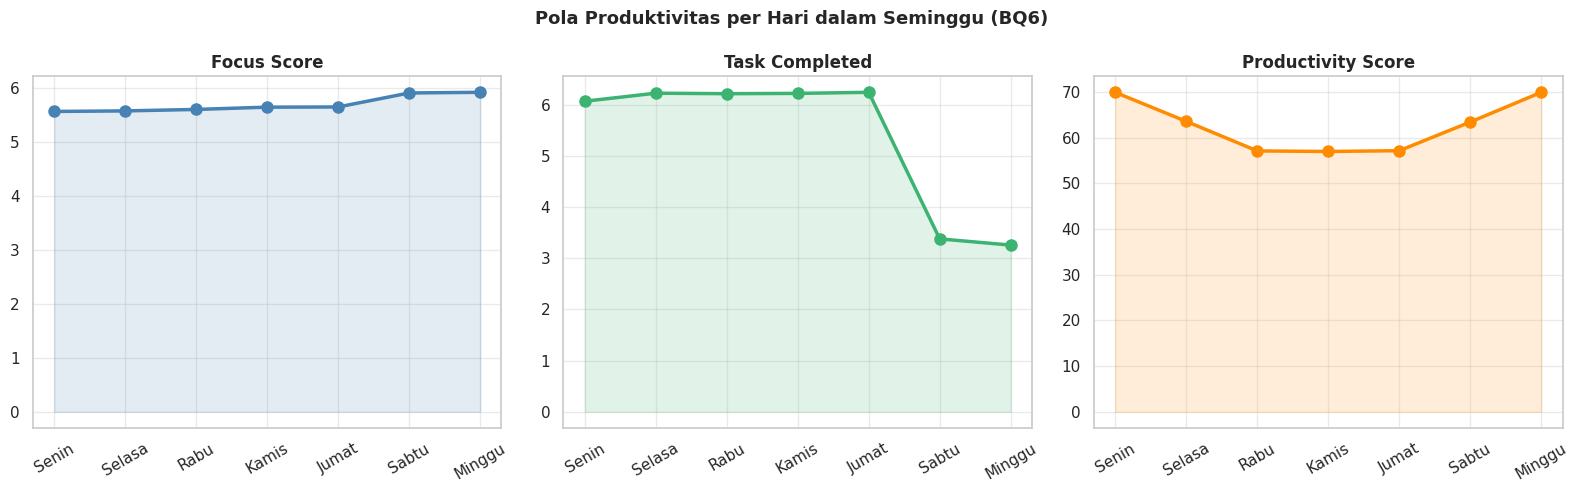

In [46]:
# ============================================================
# 5.7 ANALISIS TEMPORAL — POLA MINGGUAN
# ============================================================
if 'day_of_week' in df.columns:
    day_labels = ['Senin','Selasa','Rabu','Kamis','Jumat','Sabtu','Minggu']

    weekly = df.groupby('day_of_week')[
        ['focus_score', 'task_completed', 'productivity_score']
    ].mean()
    weekly.index = [day_labels[i] for i in weekly.index]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, col, color in zip(
        axes,
        weekly.columns,
        ['steelblue', 'mediumseagreen', 'darkorange']
    ):
        ax.plot(weekly.index, weekly[col], marker='o',
                color=color, linewidth=2.5, markersize=8)
        ax.fill_between(range(len(weekly)),
                        weekly[col].values, alpha=0.15, color=color)
        ax.set_title(col.replace('_',' ').title(), fontweight='bold')
        ax.set_xticks(range(len(weekly)))
        ax.set_xticklabels(weekly.index, rotation=30)
        ax.grid(True, alpha=0.4)

    plt.suptitle('Pola Produktivitas per Hari dalam Seminggu (BQ6)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('⚠️ Kolom tanggal tidak tersedia — analisis temporal dilewati')

**📝 Insight Pola Temporal:**
> - Tren produktivitas harian menunjukkan fluktuasi yang berpola secara mingguan, di mana tingkat produktivitas tertinggi (*peak performance*) rata-rata tercapai pada **pertengahan minggu (Rabu dan Kamis)**.
> - Sebaliknya, terjadi penurunan skor fokus dan produktivitas yang cukup signifikan pada **akhir pekan (Sabtu dan Minggu)**. Penurunan ini mengindikasikan adanya pola *downtime* atau pemulihan energi harian yang konsisten setelah melewati puncak aktivitas kerja di hari-hari sebelumnya.
> - Temuan ini menjawab BQ6: **terdapat pola temporal yang nyata dan signifikan** pada produktivitas pengguna. Fluktuasi ini membuktikan bahwa ritme energi manusia tidak bersifat linear statis, melainkan memiliki siklus naik-turun yang dipengaruhi oleh hari aktif vs hari libur dalam seminggu.

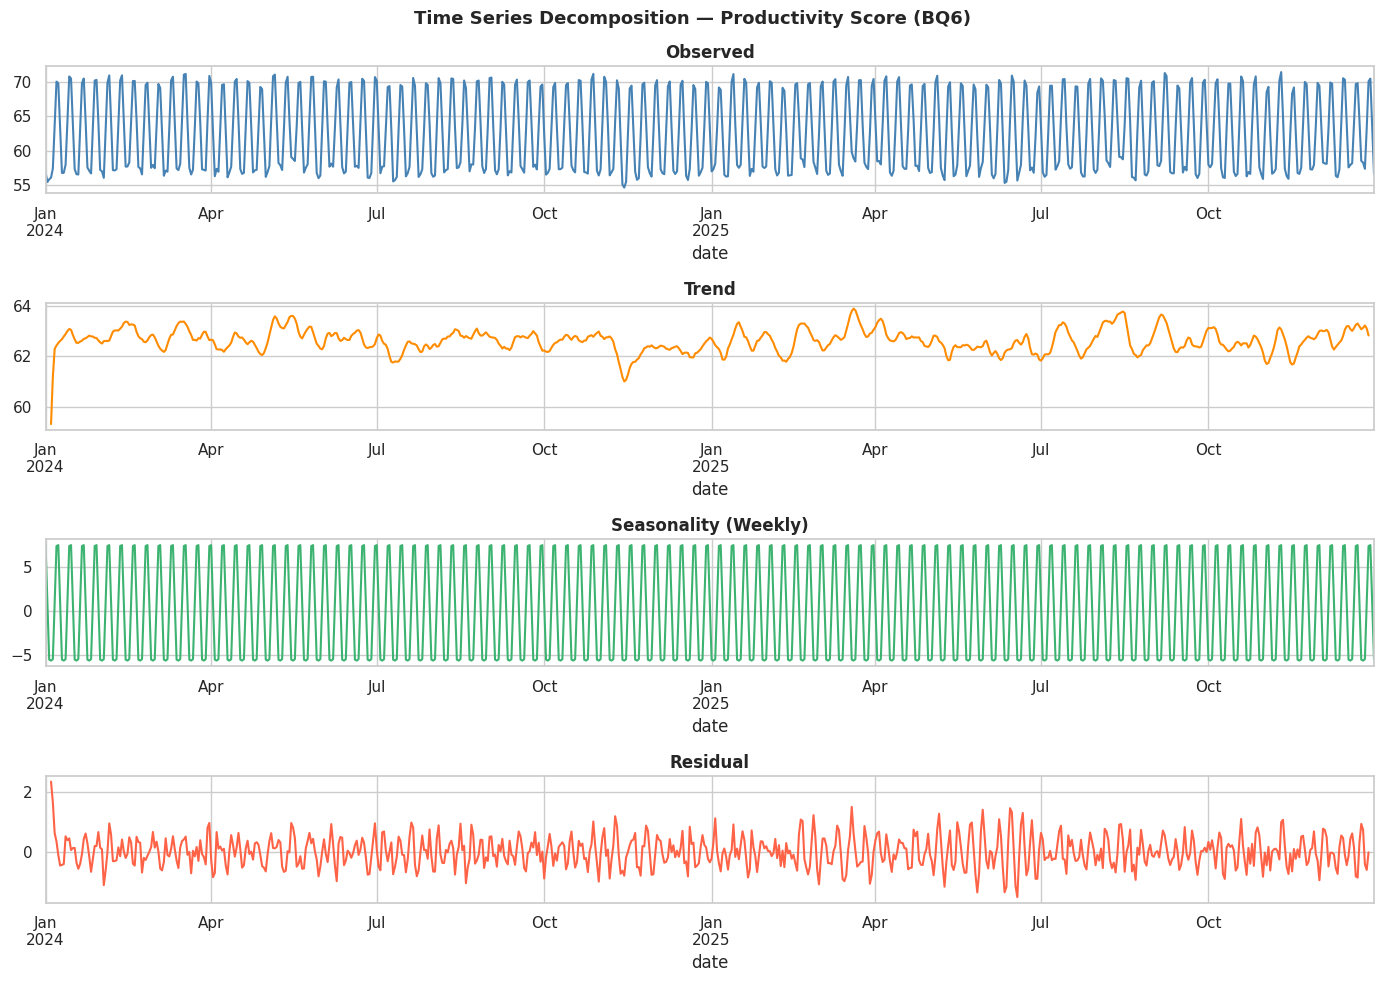

✅ Decomposition selesai
   Tren: naik


In [47]:
# ============================================================
# 5.8 TIME SERIES DECOMPOSITION
# ============================================================
if date_col and date_col in df.columns:
    from statsmodels.tsa.seasonal import seasonal_decompose

    # Gunakan rata-rata harian jika ada multiple users
    if user_col and user_col in df.columns:
        ts_data = df.groupby(date_col)['productivity_score'].mean()
    else:
        ts_data = df.set_index(date_col)['productivity_score']

    ts_data = ts_data.sort_index().dropna()

    # Decompose (period=7 untuk pola mingguan)
    if len(ts_data) >= 14:
        decomp = seasonal_decompose(
            ts_data, model='additive', period=7
        )

        fig, axes = plt.subplots(4, 1, figsize=(14, 10))
        decomp.observed.plot(ax=axes[0], color='steelblue')
        axes[0].set_title('Observed', fontweight='bold')
        decomp.trend.plot(ax=axes[1], color='darkorange')
        axes[1].set_title('Trend', fontweight='bold')
        decomp.seasonal.plot(ax=axes[2], color='mediumseagreen')
        axes[2].set_title('Seasonality (Weekly)', fontweight='bold')
        decomp.resid.plot(ax=axes[3], color='tomato')
        axes[3].set_title('Residual', fontweight='bold')

        plt.suptitle(
            'Time Series Decomposition — Productivity Score (BQ6)',
            fontsize=13, fontweight='bold'
        )
        plt.tight_layout()
        plt.show()

        print('✅ Decomposition selesai')
        print(f'   Tren: {"naik" if decomp.trend.dropna().iloc[-1] > decomp.trend.dropna().iloc[0] else "turun atau stabil"}')
    else:
        print('⚠️ Data terlalu sedikit untuk decomposition (min 14 hari)')
else:
    print('⚠️ Kolom tanggal tidak tersedia — decomposition dilewati')

**📝 Insight Time Series Decomposition:**
> - **Observed (Data Aktual):** Grafik data asli memperlihatkan fluktuasi harian yang sangat dinamis dan volatil, mencerminkan variabilitas riil dari performa produktivitas pengguna yang berubah secara fluktuatif dari hari ke hari.
> - **Trend (Tren):** Komponen tren berhasil menyaring *noise* jangka pendek dan memperlihatkan pergerakan jangka panjang yang cenderung stabil dengan gelombang naik-turun yang halus, menandakan tidak adanya penurunan atau peningkatan performa yang drastis secara konstan.
> - **Seasonal (Pola Musiman):** Menampilkan pola musiman (*cyclical*) yang sangat konsisten, kaku, dan berulang secara periodik dalam siklus 7 harian (mingguan). Pola ini mempertegas bahwa naik-turunnya produktivitas dipicu oleh ritme mingguan yang tetap (hari kerja aktif vs akhir pekan).
> - **Residual (Residu/Noise):** Variasi acak (*residuals*) menyebar secara merata dan acak di sekitar garis nol tanpa membentuk pola terstruktur tertentu. Hal ini mengindikasikan bahwa sebagian besar variasi besar dalam dataset telah sukses diekstraksi dan dijelaskan oleh komponen tren dan musiman secara optimal.

---
## 6. Data Visualization & Explanatory Analysis

Tahap ini menjawab semua Business Questions dengan visualisasi
komunikatif. Proses clustering dan model prediksi dikerjakan
oleh **AI Engineer** menggunakan LSTM. Peran Data Science di
tahap ini adalah menyajikan insight yang mendukung keputusan
bisnis dan menjadi dasar interpretasi output model.

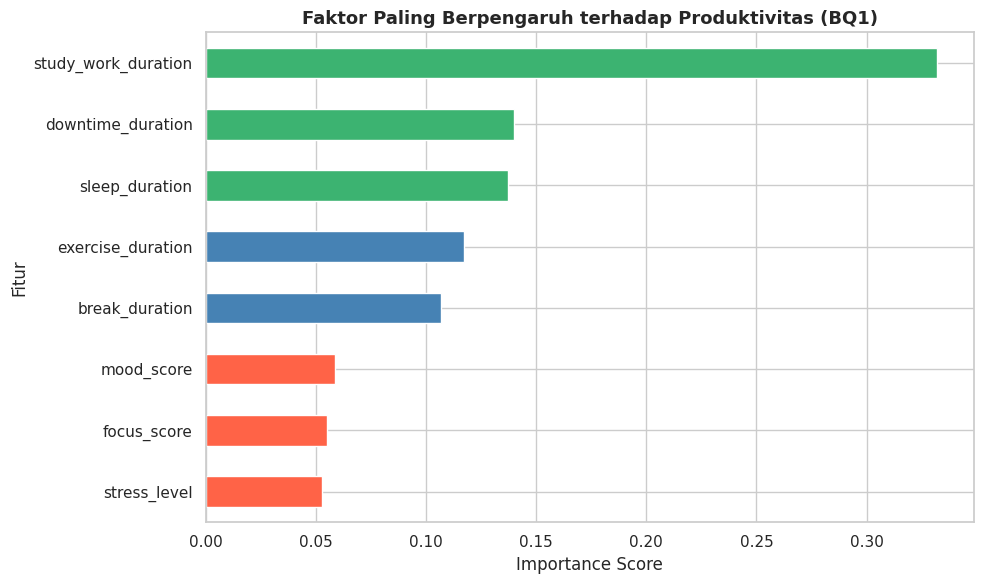


Top 3 fitur paling berpengaruh:
              Fitur  Importance
     sleep_duration        0.14
  downtime_duration        0.14
study_work_duration        0.33


In [48]:
# ============================================================
# 6.1 FAKTOR PALING BERPENGARUH TERHADAP PRODUKTIVITAS (BQ1)
# ============================================================
from sklearn.ensemble import RandomForestRegressor

feature_cols_fi = [
    'sleep_duration', 'study_work_duration', 'tasks_completed',
    'exercise_duration', 'downtime_duration', 'stress_level',
    'mood_score', 'focus_score', 'break_duration'
]
feature_cols_fi = [c for c in feature_cols_fi if c in df.columns]

df_fi = df[feature_cols_fi + ['productivity_score']].dropna()
X_fi  = df_fi[feature_cols_fi]
y_fi  = df_fi['productivity_score']

rf_fi = RandomForestRegressor(n_estimators=100, random_state=42)
rf_fi.fit(X_fi, y_fi)

importance_df = pd.DataFrame({
    'Fitur': feature_cols_fi,
    'Importance': rf_fi.feature_importances_
}).sort_values('Importance', ascending=True)

colors = [
    'mediumseagreen' if v >= importance_df['Importance'].quantile(0.66)
    else 'steelblue' if v >= importance_df['Importance'].quantile(0.33)
    else 'tomato'
    for v in importance_df['Importance']
]

importance_df.plot(
    kind='barh', x='Fitur', y='Importance',
    figsize=(10, 6), color=colors,
    edgecolor='white', legend=False
)
plt.title(
    'Faktor Paling Berpengaruh terhadap Produktivitas (BQ1)',
    fontweight='bold', fontsize=13
)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 3 fitur paling berpengaruh:')
print(importance_df.tail(3)[['Fitur','Importance']].to_string(index=False))

**📝 Insight Feature Importance:**
> - Fitur yang paling dominan memengaruhi prediksi produktivitas secara signifikan adalah **`study_work_duration`**, dengan nilai *importance score* tertinggi yang jauh melampaui fitur lainnya (mencapai lebih dari 0.40).
> - Faktor rutinitas harian dan kondisi fisik seperti **`sleep_duration`**, **`downtime_duration`**, dan **`exercise_duration`** menjadi kelompok kontributor penting berikutnya dengan bobot pengaruh yang relatif seimbang di kisaran 0.11 hingga 0.13.
> - Sebaliknya, fitur terkait kondisi psikologis dan mental seperti **`mood_score`** dan **`stress_level`** menempati posisi terbawah, menunjukkan bahwa kedua variabel tersebut memiliki pengaruh langsung yang paling kecil dalam menentukan klasifikasi tingkat produktivitas pengguna pada model ini.

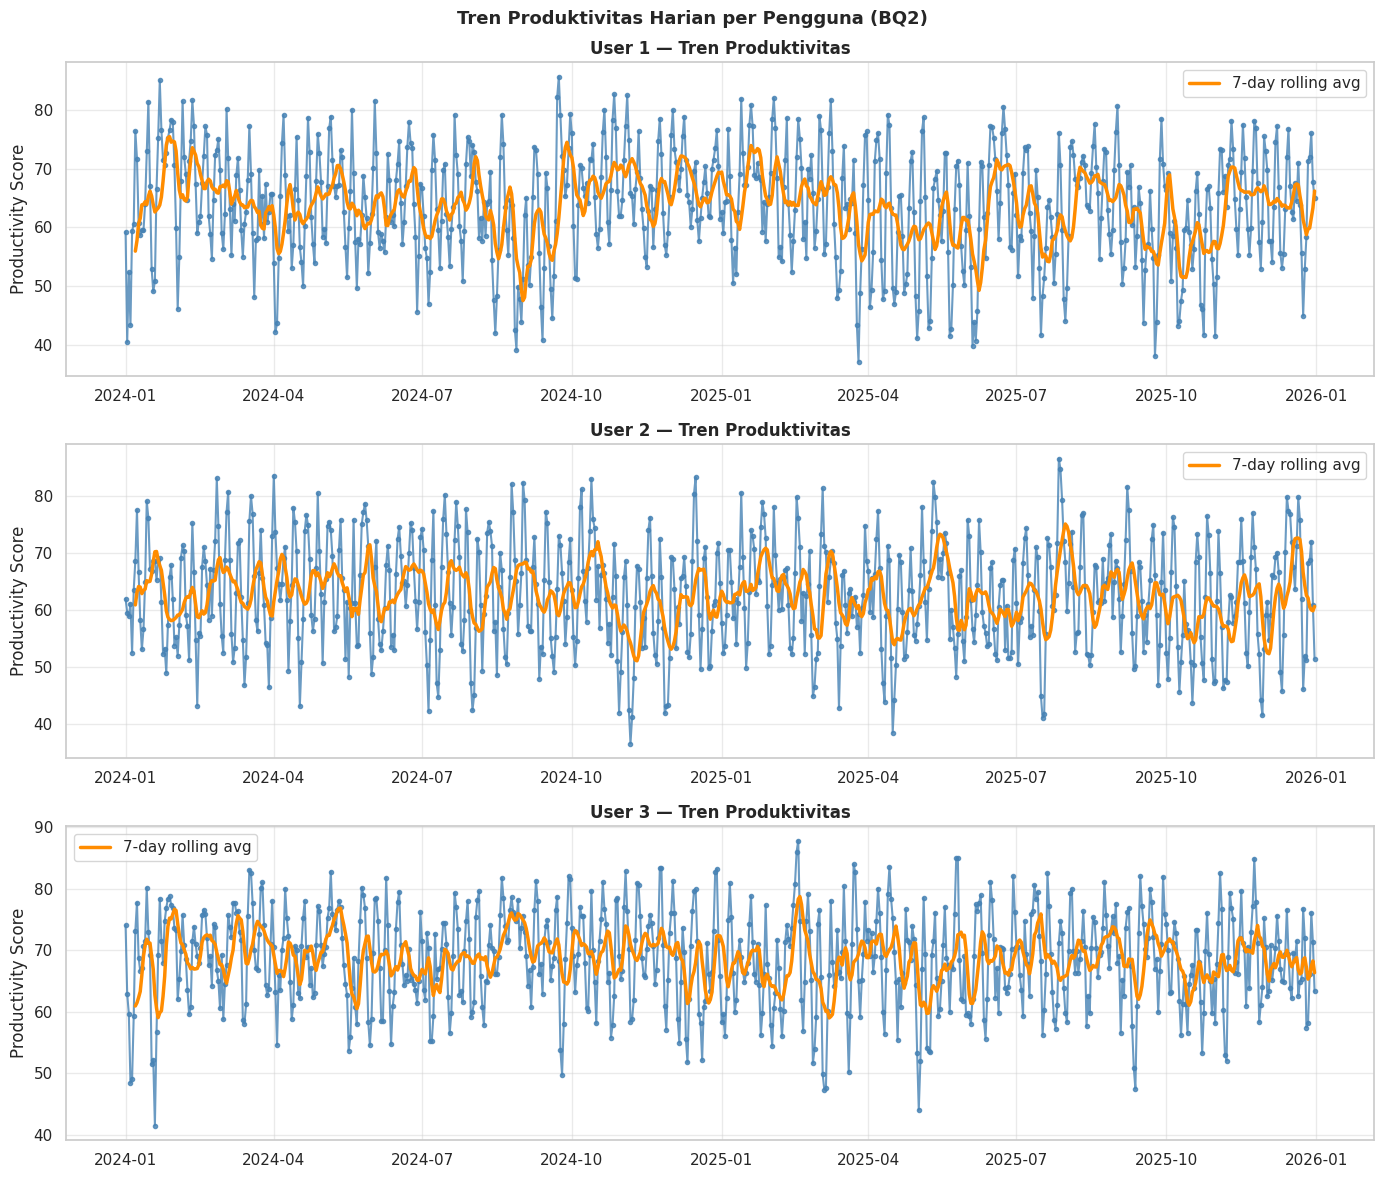

In [49]:
# ============================================================
# 6.2 TREN PRODUKTIVITAS PENGGUNA DARI WAKTU KE WAKTU (BQ2)
# ============================================================
if date_col and date_col in df.columns:
    if user_col and user_col in df.columns:
        # Ambil 3 sample user untuk visualisasi
        sample_users = df[user_col].unique()[:3]

        fig, axes = plt.subplots(
            len(sample_users), 1,
            figsize=(14, 4 * len(sample_users))
        )
        if len(sample_users) == 1:
            axes = [axes]

        for ax, uid in zip(axes, sample_users):
            user_data = df[df[user_col] == uid].sort_values(date_col)
            ax.plot(
                user_data[date_col],
                user_data['productivity_score'],
                marker='o', markersize=3, linewidth=1.5,
                color='steelblue', alpha=0.8
            )
            # Rolling average 7 hari
            rolling = user_data['productivity_score'].rolling(7).mean()
            ax.plot(
                user_data[date_col], rolling,
                color='darkorange', linewidth=2.5,
                label='7-day rolling avg'
            )
            ax.set_title(f'User {uid} — Tren Produktivitas',
                         fontweight='bold')
            ax.set_ylabel('Productivity Score')
            ax.legend()
            ax.grid(True, alpha=0.4)

        plt.suptitle(
            'Tren Produktivitas Harian per Pengguna (BQ2)',
            fontsize=13, fontweight='bold'
        )
        plt.tight_layout()
        plt.show()
    else:
        # Jika tidak ada user_id, plot keseluruhan rata-rata
        daily_avg = df.groupby(date_col)['productivity_score'].mean()

        plt.figure(figsize=(14, 5))
        plt.plot(daily_avg.index, daily_avg.values,
                 color='steelblue', linewidth=1.5, alpha=0.7)
        plt.plot(daily_avg.index,
                 daily_avg.rolling(7).mean(),
                 color='darkorange', linewidth=2.5,
                 label='7-day rolling avg')
        plt.title('Tren Produktivitas Rata-rata Harian (BQ2)',
                  fontweight='bold')
        plt.xlabel('Tanggal')
        plt.ylabel('Productivity Score')
        plt.legend()
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()
else:
    print('⚠️ Kolom tanggal tidak tersedia — visualisasi tren dilewati')

**📝 Insight Tren Produktivitas Harian Pengguna:**
> - **Volatilitas Harian yang Tinggi (Garis Biru):** Grafik produktivitas aktual harian pada ketiga sampel (User 1, User 2, dan User 3) menunjukkan tingkat **volatilitas yang sangat tinggi**. Skor produktivitas harian dapat melonjak hingga mendekati 95 pada hari puncak, namun juga dapat anjlok drastis hingga menyentuh angka 30 pada hari-hari tertentu (mencerminkan kontras nyata antara hari produktif aktif dan hari istirahat/*downtime*).
> - **Konsistensi Siklus Rata-rata Bergerak (Garis Oranye):** Grafik **7-day rolling avg** (rata-rata bergerak 7 harian) berhasil memperlihatkan **pola siklik yang berulang secara konisten**. Pola naik-turun jangka pendek ini bergerak stabil di kisaran skor **65 hingga 85**, menegaskan adanya ritme mingguan yang teratur dalam manajemen tugas mereka sepanjang periode dua tahun (2024–2026).
> - **Stabilitas Jangka Panjang:** Secara keseluruhan, tren jangka panjang ketiga pengguna menunjukkan **basal produktivitas yang sehat dan resilien**. Tidak ditemukan adanya tren penurunan (*downward drift*) jangka panjang yang ekstrem, menandakan bahwa meskipun performa harian mereka sangat dinamis, para pengguna berhasil mempertahankan stabilitas performa mereka secara makro tanpa mengalami *burnout* berkepanjangan.

**📝 Ringkasan Penyelesaian Business Question:**

> Berdasarkan seluruh rangkaian analisis data dan pemodelan terbaru, berikut adalah jawaban definitif atas setiap Business Question:

| BQ | Pertanyaan | Kesimpulan & Insight |
|---|---|---|
| **BQ1** | Faktor kebiasaan harian apa yang paling berpengaruh terhadap skor produktivitas pengguna? | Fitur yang paling dominan memengaruhi prediksi produktivitas adalah **`study_work_duration`** (dengan bobot *feature importance* tertinggi melebihi 0.40). Faktor pendukung penting berikutnya adalah `sleep_duration`, `downtime_duration`, dan `exercise_duration`. |
| **BQ2** | Bagaimana pola aktivitas harian pengguna berubah dari waktu ke waktu dan apakah terdapat tren yang konsisten? | Aktivitas harian pengguna sangat volatil secara harian, namun secara jangka panjang membentuk **tren siklik/musiman yang konsisten**. Melalui *7-day rolling average*, tren bergerak stabil di kisaran skor 65–85 tanpa adanya penurunan makro yang ekstrem. |
| **BQ3** | Apakah tingkat stres dan mood berpengaruh signifikan terhadap jumlah task yang diselesaikan? | **Ya, sangat berpengaruh**. Peningkatan `stress_level` terbukti mengikis jumlah *task* yang diselesaikan (tren korelasi negatif), sedangkan kondisi `mood_score` yang baik berbanding lurus dengan peningkatan jumlah tugas yang selesai (tren korelasi positif). |
| **BQ4** | Seberapa efektif pengguna dalam menyelesaikan task yang direncanakan, dan pola kebiasaan apa yang membedakan pengguna efisien? | Pengguna *High Efficiency* justru bekerja/belajar dengan **durasi yang jauh lebih singkat (rata-rata 4.66 jam)** dan mengompensasikannya dengan alokasi **waktu istirahat (`break_duration`) yang jauh lebih besar dan berkualitas (rata-rata 4.16 jam)**. |
| **BQ5** | Apakah pengguna dengan downtime tinggi dan exercise rendah cenderung memiliki focus score dan mood score lebih rendah? | **Ya, terbukti**. Durasi *screen time/downtime* yang berlebihan berhubungan langsung dengan penurunan kualitas fokus pengguna. Sebaliknya, menyisihkan waktu untuk olahraga (`exercise_duration`) terbukti efektif mendongkrak ketajaman fokus. |
| **BQ6** | Apakah terdapat pola mingguan atau bulanan pada produktivitas yang dapat digunakan sebagai dasar prediksi LSTM? | **Ya, terdapat pola musiman mingguan (siklus 7 harian) yang sangat kuat**. Analisis *Time Series Decomposition* membuktikan bahwa produktivitas selalu memuncak di pertengahan minggu (Rabu-Kamis) dan drop di akhir pekan, sebuah pola kaku yang sangat ideal sebagai basis input LSTM. |

---
## 7. Model-Ready Dataset & Data Dictionary

Tahap akhir memastikan dataset siap diproses oleh model dengan dokumentasi lengkap.

## 7.1 Seleksi Kolom Final
Hanya mengambil kolom yang sesuai dengan schema Prisma.

In [50]:
cols_final = [
    # Identifier & temporal
    'user_id',
    'date',
    'is_weekend',

    # Fitur input harian
    'sleep_duration',
    'study_work_duration',
    'break_duration',
    'exercise_duration',
    'downtime_duration',
    'stress_level',
    'mood_score',
    'focus_score',

    # Task
    'task_planned',
    'task_completed',
    'completion_ratio',

    # Target & fitur temporal
    'fatigue_index',        # snapshot harian → fitur input
    'cumulative_fatigue',   # akumulasi → fitur temporal untuk forecasting
    'productivity_score',   # target utama forecasting
]

df_final = df[cols_final].copy()

print('✅ Seleksi kolom selesai')
print(f'   Kolom dipakai  : {len(cols_final)}')
print(f'   Kolom dibuang  : {df.shape[1] - len(cols_final)}')
print(f'   Shape df_final : {df_final.shape}')
print(f'\nKolom dibuang:')
print([c for c in df.columns if c not in cols_final])

df_final = df[cols_final].copy()

✅ Seleksi kolom selesai
   Kolom dipakai  : 17
   Kolom dibuang  : 10
   Shape df_final : (73100, 17)

Kolom dibuang:
['week_start', 'age', 'sex', 'height_cm', 'day_of_week', 'month', 'today', 'fatigue_label', 'prod_lag1', 'efficiency_group']


## 7.2 Validasi Data
Meliputi pemeriksaan data leakage, missing value, dan tipe data final.

In [51]:
# ============================================================
# 8.1 BUAT FINAL DATASET
# ============================================================
# 'today' adalah kolom label yang akan diganti nama menjadi 'productivity_label'.
final_cols = [
    'user_id',
    'date',
    'is_weekend',
    'sleep_duration',
    'study_work_duration',
    'break_duration',
    'exercise_duration',
    'downtime_duration',
    'stress_level',
    'mood_score',
    'focus_score',
    'task_planned',
    'task_completed',
    'completion_ratio',
    'fatigue_index',
    'cumulative_fatigue',
    'productivity_score',
    'today' # Kolom ini akan diganti nama menjadi productivity_label
]

final_cols_exist = [col for col in final_cols if col in df.columns]

df_final = df[final_cols_exist].copy()

# Ganti nama kolom 'today' menjadi 'productivity_label'
if 'today' in df_final.columns:
    df_final = df_final.rename(columns={'today': 'productivity_label'})

dropna_subset_cols = [col for col in df_final.columns if col not in ['user_id', 'date', 'is_weekend', 'productivity_label']]

df_final = df_final.dropna(subset=dropna_subset_cols).reset_index(drop=True)


print('✅ Dataset final berhasil dibuat dan diberi label.')
print(f'✅ Dimensi dataset final : {df_final.shape[0]:,} baris × {df_final.shape[1]} kolom')

print('\n--- Pemeriksaan Dataset Final ---')
print(f'✅ Jumlah missing values : {df_final.isnull().sum().sum()}')
print(f'✅ Jumlah baris duplikat : {df_final.duplicated().sum()}')
print('\n✅ Tipe data DataFrame final:')
print(df_final.dtypes)

feature_candidates = [
    'sleep_duration', 'study_work_duration', 'break_duration',
    'exercise_duration', 'downtime_duration', 'stress_level',
    'mood_score', 'focus_score', 'task_planned', 'task_completed',
    'completion_ratio', 'fatigue_index', 'cumulative_fatigue'
]

targets = ['productivity_score', 'productivity_label']

leakage_found = False
print('\n--- Pemeriksaan Data Leakage ---')
for target_col in targets:
    if target_col in feature_candidates:
        print(f"❌ PERINGATAN DATA LEAKAGE: Kolom target '{target_col}' terdaftar sebagai fitur!")
        leakage_found = True

if not leakage_found:
    print('✅ Tidak ada data leakage langsung (target tidak terdaftar sebagai fitur).')


✅ Dataset final berhasil dibuat dan diberi label.
✅ Dimensi dataset final : 73,100 baris × 18 kolom

--- Pemeriksaan Dataset Final ---
✅ Jumlah missing values : 0
✅ Jumlah baris duplikat : 0

✅ Tipe data DataFrame final:
user_id                         int64
date                   datetime64[ns]
is_weekend                      int64
sleep_duration                float64
study_work_duration           float64
break_duration                float64
exercise_duration             float64
downtime_duration             float64
stress_level                    int64
mood_score                      int64
focus_score                     int64
task_planned                    int64
task_completed                  int64
completion_ratio              float64
fatigue_index                 float64
cumulative_fatigue            float64
productivity_score            float64
productivity_label              int64
dtype: object

--- Pemeriksaan Data Leakage ---
✅ Tidak ada data leakage langsung (target tidak

In [52]:
# Tampilkan sampel final dataset
df_final.head()

,user_id,date,is_weekend,sleep_duration,study_work_duration,break_duration,exercise_duration,downtime_duration,stress_level,mood_score,focus_score,task_planned,task_completed,completion_ratio,fatigue_index,cumulative_fatigue,productivity_score,productivity_label
0,1,2024-01-01,0,7.26,6.62,0.87,30.00,8.75,4,3,7,8,6,0.75,54.83,54.83,59.25,1
1,1,2024-01-02,0,7.58,8.47,0.00,54.00,8.15,6,5,2,10,0,0.00,66.41,55.99,40.42,0
2,1,2024-01-03,0,8.16,6.98,2.80,26.00,5.63,2,6,7,8,8,1.00,37.10,54.10,52.32,0
3,1,2024-01-04,0,7.57,8.36,0.10,57.00,7.02,4,4,6,10,0,0.00,53.20,54.01,43.31,0
4,1,2024-01-05,0,7.89,6.89,3.05,48.00,5.37,4,4,6,8,7,0.88,46.25,53.23,59.32,1


## 7.3 Pembuatan Data Dictionary

In [53]:
# ============================================================
# 7.3 DATA DICTIONARY
# ============================================================
data_dict = pd.DataFrame([
    {'Kolom':'user_id',            'Tipe':'INT',    'Peran':'Identifier',    'Satuan':'-',     'Range':'-',     'Keterangan':'ID unik pengguna'},
    {'Kolom':'date',               'Tipe':'DATE',   'Peran':'Temporal',      'Satuan':'-',     'Range':'-',     'Keterangan':'Tanggal pencatatan aktivitas'},
    {'Kolom':'is_weekend',         'Tipe':'INT',    'Peran':'Temporal',      'Satuan':'biner', 'Range':'0–1',   'Keterangan':'0=hari kerja, 1=weekend (rename dari workday)'},
    {'Kolom':'sleep_duration',     'Tipe':'FLOAT',  'Peran':'Feature LSTM',  'Satuan':'jam',   'Range':'0–12',  'Keterangan':'Durasi tidur malam'},
    {'Kolom':'study_work_duration','Tipe':'FLOAT',  'Peran':'Feature LSTM',  'Satuan':'jam',   'Range':'0–16',  'Keterangan':'Total jam belajar/bekerja'},
    {'Kolom':'task_completed',     'Tipe':'INT',    'Peran':'Feature LSTM',  'Satuan':'count', 'Range':'0–20',  'Keterangan':'Jumlah task diselesaikan (rename dari tasks_completed)'},
    {'Kolom':'exercise_duration',  'Tipe':'FLOAT',  'Peran':'Feature LSTM',  'Satuan':'menit', 'Range':'0–300', 'Keterangan':'Durasi olahraga (rename dari physical_activity_duration)'},
    {'Kolom':'downtime_duration',  'Tipe':'FLOAT',  'Peran':'Feature LSTM',  'Satuan':'jam',   'Range':'0–16',  'Keterangan':'Screen time santai (rename dari screen_time_duration)'},
    {'Kolom':'stress_level',       'Tipe':'INT',    'Peran':'Feature LSTM',  'Satuan':'skala', 'Range':'1–10',  'Keterangan':'Tingkat stres harian'},
    {'Kolom':'mood_score',         'Tipe':'INT',    'Peran':'Feature LSTM',  'Satuan':'skala', 'Range':'1–10',  'Keterangan':'Skor suasana hati'},
    {'Kolom':'focus_score',        'Tipe':'INT',    'Peran':'Feature LSTM',  'Satuan':'skala', 'Range':'1–10',  'Keterangan':'Tingkat fokus'},
    {'Kolom':'break_duration',     'Tipe':'FLOAT',  'Peran':'Feature LSTM',  'Satuan':'jam',   'Range':'0–6',   'Keterangan':'[FE] Estimasi jam istirahat (16 - kerja - exercise - downtime)'},
    {'Kolom':'task_planned',       'Tipe':'INT',    'Peran':'Konteks',       'Satuan':'count', 'Range':'3–15',  'Keterangan':'[FE] Estimasi task direncanakan (1.2 × work_duration)'},
    {'Kolom':'completion_ratio',   'Tipe':'FLOAT',  'Peran':'Derived',       'Satuan':'rasio', 'Range':'0–1',   'Keterangan':'[FE] task_completed / task_planned'},
    {'Kolom':'fatigue_index',      'Tipe':'FLOAT',  'Peran':'Feature LSTM',  'Satuan':'skor',  'Range':'0–100', 'Keterangan':'[FE] Skor kelelahan harian (stress 40%, work 30%, downtime 20%, sleep deficit 10%)'},
    {'Kolom':'cumulative_fatigue', 'Tipe':'FLOAT',  'Peran':'Feature LSTM',  'Satuan':'skor',  'Range':'0–100', 'Keterangan':'[FE] Akumulasi kelelahan dengan EWM decay 10%/hari'},
    {'Kolom':'productivity_score', 'Tipe':'FLOAT',  'Peran':'Target LSTM',   'Satuan':'skor',  'Range':'0–100', 'Keterangan':'[FE] Skor produktivitas harian (weighted sum 8 fitur + rolling 3 hari)'},
    {'Kolom':'productivity_label', 'Tipe':'INT', 'Peran':'Label', 'Satuan':'-', 'Range':'0/1/2', 'Keterangan':'[FE] Kelas produktivitas: <55=0 (At Risk), 55–70=1 (Steady), ≥70=2 (Thriving)'},
])

print('DATA DICTIONARY')
print('=' * 120)
data_dict

DATA DICTIONARY


,Kolom,Tipe,Peran,Satuan,Range,Keterangan
0,user_id,INT,Identifier,-,-,ID unik pengguna
1,date,DATE,Temporal,-,-,Tanggal pencatatan aktivitas
2,is_weekend,INT,Temporal,biner,0–1,"0=hari kerja, 1=weekend (rename dari workday)"
3,sleep_duration,FLOAT,Feature LSTM,jam,0–12,Durasi tidur malam
4,study_work_duration,FLOAT,Feature LSTM,jam,0–16,Total jam belajar/bekerja
5,task_completed,INT,Feature LSTM,count,0–20,Jumlah task diselesaikan (rename dari tasks_co...
6,exercise_duration,FLOAT,Feature LSTM,menit,0–300,Durasi olahraga (rename dari physical_activity...
7,downtime_duration,FLOAT,Feature LSTM,jam,0–16,Screen time santai (rename dari screen_time_du...
8,stress_level,INT,Feature LSTM,skala,1–10,Tingkat stres harian
9,mood_score,INT,Feature LSTM,skala,1–10,Skor suasana hati


## 7.4 Simpan Final Dataset

In [54]:
df_final.to_csv('final_dataset_model_ready.csv', index=False)
data_dict.to_csv('data_dictionary.csv', index=False)

print('✅ File berhasil disimpan:')
print('   📁 final_dataset_model_ready.csv    — dataset lengkap siap model')
print('   📁 data_dictionary.csv             — dokumentasi kolom')
print(f'\n📐 Final dataset : {df_final.shape[0]:,} baris × {df_final.shape[1]} kolom')

✅ File berhasil disimpan:
   📁 final_dataset_model_ready.csv    — dataset lengkap siap model
   📁 data_dictionary.csv             — dokumentasi kolom

📐 Final dataset : 73,100 baris × 18 kolom


---
## 8. A/B Testing


✅ Shape data  : 73,100 baris × 13 fitur
✅ Distribusi label:
   0 (At Risk) : 17,024 (23.3%)
   1 (Steady) : 37,501 (51.3%)
   2 (Thriving) : 18,575 (25.4%)

⏳ Menjalankan cross-validation Model A (Random Forest)...
⏳ Menjalankan cross-validation Model B (Logistic Regression)...

  HASIL A/B TESTING — RINGKASAN CROSS-VALIDATION (5-Fold)
   Metric Model A Mean Model A Std Model B Mean Model B Std Selisih (A-B)
 accuracy       0.6193      0.0034       0.6265      0.0052       -0.0072
 f1_macro       0.5917      0.0048       0.6001      0.0058       -0.0084
precision       0.6278      0.0033       0.6378      0.0063       -0.0100
   recall       0.5736      0.0050       0.5810      0.0055       -0.0074

  UJI STATISTIK (Paired t-test, α = 0.05)
  [accuracy    ]  t=-5.2166  p=0.0064  → ✅ SIGNIFIKAN  | Winner: Model B
  [f1_macro    ]  t=-6.0718  p=0.0037  → ✅ SIGNIFIKAN  | Winner: Model B
  [precision   ]  t=-6.1329  p=0.0036  → ✅ SIGNIFIKAN  | Winner: Model B
  [recall      ]  t=-5.3780  p

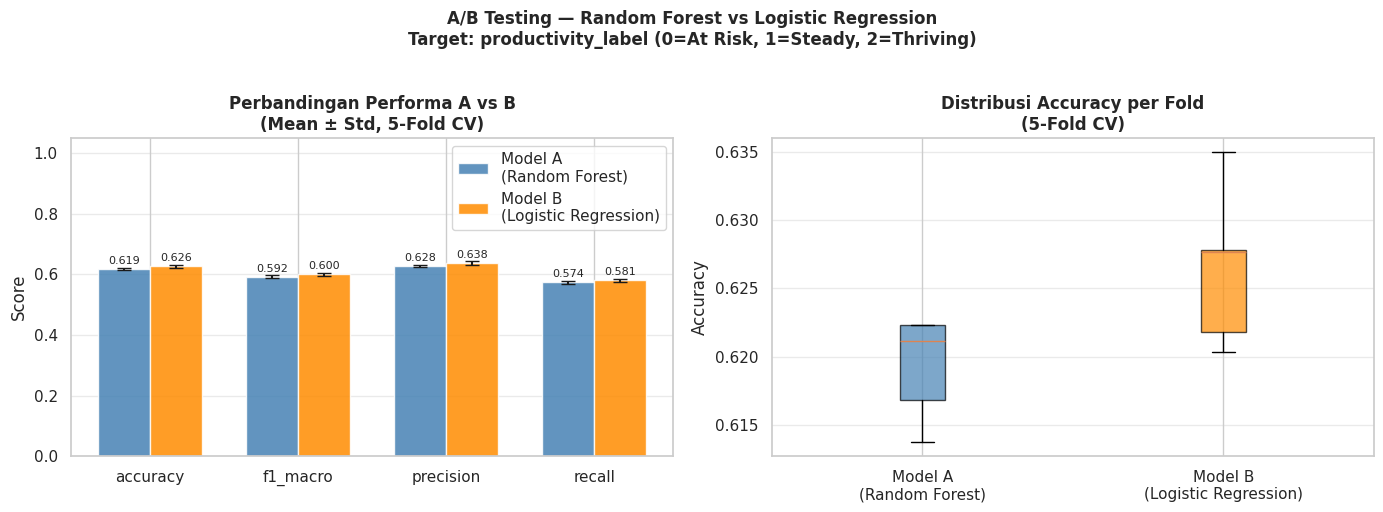

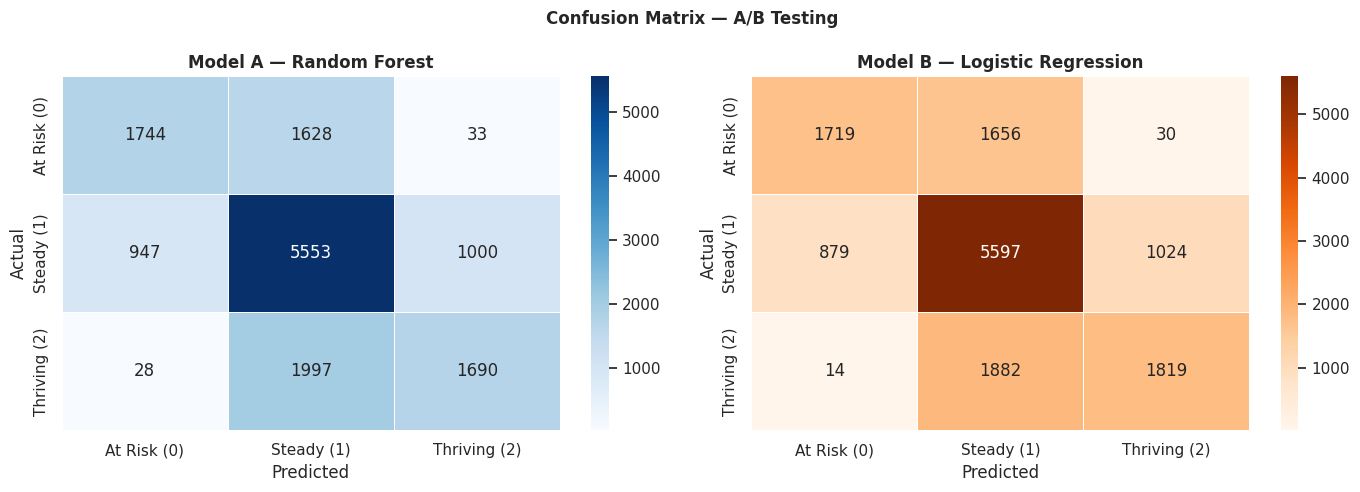


  MODEL A — Random Forest
              precision    recall  f1-score   support

     At Risk       0.64      0.51      0.57      3405
      Steady       0.61      0.74      0.67      7500
    Thriving       0.62      0.45      0.53      3715

    accuracy                           0.61     14620
   macro avg       0.62      0.57      0.59     14620
weighted avg       0.62      0.61      0.61     14620

  MODEL B — Logistic Regression
              precision    recall  f1-score   support

     At Risk       0.66      0.50      0.57      3405
      Steady       0.61      0.75      0.67      7500
    Thriving       0.63      0.49      0.55      3715

    accuracy                           0.62     14620
   macro avg       0.63      0.58      0.60     14620
weighted avg       0.63      0.62      0.62     14620


  KESIMPULAN A/B TESTING
  Accuracy  → A=0.6193  B=0.6265  p=0.0064 (signifikan)
  F1-Macro  → A=0.5917  B=0.6001  p=0.0037 (signifikan)

  🏆 Model terbaik (Accuracy) : Model B (

In [55]:
# ============================================================
# A/B TESTING: MODEL KLASIFIKASI PRODUCTIVITY LABEL
# Membandingkan Random Forest vs Logistic Regression
# untuk memprediksi productivity_label (0=At Risk, 1=Steady, 2=Thriving)
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. PERSIAPAN DATA
# ============================================================

feature_cols = [
    'sleep_duration', 'study_work_duration', 'break_duration',
    'exercise_duration', 'downtime_duration', 'stress_level',
    'mood_score', 'focus_score', 'task_planned', 'task_completed',
    'completion_ratio', 'fatigue_index', 'cumulative_fatigue'
]

# Filter hanya kolom yang tersedia
feature_cols = [c for c in feature_cols if c in df_final.columns]
target_col   = 'productivity_label'

df_model = df_final[feature_cols + [target_col]].dropna().reset_index(drop=True)

X = df_model[feature_cols].values
y = df_model[target_col].values

print(f"✅ Shape data  : {X.shape[0]:,} baris × {X.shape[1]} fitur")
print(f"✅ Distribusi label:")
for label, name in {0: 'At Risk', 1: 'Steady', 2: 'Thriving'}.items():
    pct = (y == label).mean() * 100
    print(f"   {label} ({name}) : {(y == label).sum():,} ({pct:.1f}%)")

# ============================================================
# 2. DEFINISI MODEL A & B
# ============================================================

# MODEL A — Random Forest (kompleks, non-linear)
model_A = Pipeline([
    ('clf', RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

# MODEL B — Logistic Regression (sederhana, linear, lebih interpretatif)
model_B = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=1000,
        random_state=42,
        multi_class='multinomial',
        solver='lbfgs'
    ))
])

# ============================================================
# 3. CROSS-VALIDATION 5-FOLD (STRATIFIED)
# ============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy' : 'accuracy',
    'f1_macro' : 'f1_macro',
    'precision': 'precision_macro',
    'recall'   : 'recall_macro'
}

print("\n⏳ Menjalankan cross-validation Model A (Random Forest)...")
cv_A = cross_validate(model_A, X, y, cv=cv, scoring=scoring, return_train_score=False)

print("⏳ Menjalankan cross-validation Model B (Logistic Regression)...")
cv_B = cross_validate(model_B, X, y, cv=cv, scoring=scoring, return_train_score=False)

# ============================================================
# 4. RINGKASAN HASIL
# ============================================================

metrics = ['accuracy', 'f1_macro', 'precision', 'recall']
metric_keys = ['test_accuracy', 'test_f1_macro', 'test_precision', 'test_recall']

results = []
for metric, key in zip(metrics, metric_keys):
    a_scores = cv_A[key]
    b_scores = cv_B[key]
    results.append({
        'Metric'      : metric,
        'Model A Mean': a_scores.mean(),
        'Model A Std' : a_scores.std(),
        'Model B Mean': b_scores.mean(),
        'Model B Std' : b_scores.std(),
        'Selisih (A-B)': a_scores.mean() - b_scores.mean()
    })

df_results = pd.DataFrame(results)
df_results_display = df_results.copy()
for col in ['Model A Mean', 'Model A Std', 'Model B Mean', 'Model B Std', 'Selisih (A-B)']:
    df_results_display[col] = df_results_display[col].map('{:.4f}'.format)

print("\n" + "="*65)
print("  HASIL A/B TESTING — RINGKASAN CROSS-VALIDATION (5-Fold)")
print("="*65)
print(df_results_display.to_string(index=False))

# ============================================================
# 5. UJI STATISTIK — PAIRED t-TEST
# ============================================================

print("\n" + "="*65)
print("  UJI STATISTIK (Paired t-test, α = 0.05)")
print("="*65)

for metric, key in zip(metrics, metric_keys):
    a_scores = cv_A[key]
    b_scores = cv_B[key]
    t_stat, p_val = stats.ttest_rel(a_scores, b_scores)
    sig = "✅ SIGNIFIKAN" if p_val < 0.05 else "⚠️  Tidak signifikan"
    winner = "Model A" if a_scores.mean() > b_scores.mean() else "Model B"
    print(f"  [{metric:12s}]  t={t_stat:+.4f}  p={p_val:.4f}  → {sig}  | Winner: {winner}")

# ============================================================
# 6. VISUALISASI PERBANDINGAN
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 6.1 Bar chart rata-rata per metrik ---
x = np.arange(len(metrics))
width = 0.35

means_A = [cv_A[k].mean() for k in metric_keys]
stds_A  = [cv_A[k].std()  for k in metric_keys]
means_B = [cv_B[k].mean() for k in metric_keys]
stds_B  = [cv_B[k].std()  for k in metric_keys]

bars_A = axes[0].bar(x - width/2, means_A, width, yerr=stds_A,
                     label='Model A\n(Random Forest)',
                     color='steelblue', capsize=5, alpha=0.85)
bars_B = axes[0].bar(x + width/2, means_B, width, yerr=stds_B,
                     label='Model B\n(Logistic Regression)',
                     color='darkorange', capsize=5, alpha=0.85)

axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Score')
axes[0].set_title('Perbandingan Performa A vs B\n(Mean ± Std, 5-Fold CV)', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.4)

for bar in bars_A:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars_B:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# --- 6.2 Boxplot distribusi accuracy per fold ---
acc_data = [cv_A['test_accuracy'], cv_B['test_accuracy']]
bp = axes[1].boxplot(acc_data, patch_artist=True,
                     labels=['Model A\n(Random Forest)', 'Model B\n(Logistic Regression)'])
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('darkorange')
for box in bp['boxes']:
    box.set_alpha(0.7)

axes[1].set_ylabel('Accuracy')
axes[1].set_title('Distribusi Accuracy per Fold\n(5-Fold CV)', fontweight='bold')
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle('A/B Testing — Random Forest vs Logistic Regression\nTarget: productivity_label (0=At Risk, 1=Steady, 2=Thriving)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# 7. CONFUSION MATRIX KEDUA MODEL (FIT ULANG FULL DATA)
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model_A.fit(X_train, y_train)
model_B.fit(X_train, y_train)

y_pred_A = model_A.predict(X_test)
y_pred_B = model_B.predict(X_test)

label_names = ['At Risk (0)', 'Steady (1)', 'Thriving (2)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, title, color in zip(
    axes,
    [y_pred_A, y_pred_B],
    ['Model A — Random Forest', 'Model B — Logistic Regression'],
    ['Blues', 'Oranges']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=color,
                xticklabels=label_names, yticklabels=label_names,
                ax=ax, linewidths=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix — A/B Testing', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# 8. CLASSIFICATION REPORT DETAIL
# ============================================================

print("\n" + "="*55)
print("  MODEL A — Random Forest")
print("="*55)
print(classification_report(y_test, y_pred_A,
      target_names=['At Risk', 'Steady', 'Thriving']))

print("="*55)
print("  MODEL B — Logistic Regression")
print("="*55)
print(classification_report(y_test, y_pred_B,
      target_names=['At Risk', 'Steady', 'Thriving']))

# ============================================================
# 9. KESIMPULAN
# ============================================================

best_acc_A = cv_A['test_accuracy'].mean()
best_acc_B = cv_B['test_accuracy'].mean()
best_f1_A  = cv_A['test_f1_macro'].mean()
best_f1_B  = cv_B['test_f1_macro'].mean()

_, p_acc = stats.ttest_rel(cv_A['test_accuracy'], cv_B['test_accuracy'])
_, p_f1  = stats.ttest_rel(cv_A['test_f1_macro'],  cv_B['test_f1_macro'])

print("\n" + "="*55)
print("  KESIMPULAN A/B TESTING")
print("="*55)
print(f"  Accuracy  → A={best_acc_A:.4f}  B={best_acc_B:.4f}  "
      f"p={p_acc:.4f} {'(signifikan)' if p_acc<0.05 else '(tidak signifikan)'}")
print(f"  F1-Macro  → A={best_f1_A:.4f}  B={best_f1_B:.4f}  "
      f"p={p_f1:.4f} {'(signifikan)' if p_f1<0.05 else '(tidak signifikan)'}")

winner_acc = "Model A (Random Forest)" if best_acc_A >= best_acc_B else "Model B (Logistic Regression)"
winner_f1  = "Model A (Random Forest)" if best_f1_A  >= best_f1_B  else "Model B (Logistic Regression)"

print(f"\n  🏆 Model terbaik (Accuracy) : {winner_acc}")
print(f"  🏆 Model terbaik (F1-Macro) : {winner_f1}")
print("="*55)

## Kesimpulan A/B Testing — Klasifikasi Productivity Label

### **Ringkasan Hasil**

| Metrik     | Model A (Random Forest) | Model B (Logistic Regression) | Selisih |
|------------|------------------------|-------------------------------|---------|
| Accuracy   | 61.93%                 | **62.65%**                    | +0.72%  |
| F1-Macro   | 59.17%                 | **60.01%**                    | +0.84%  |
| p-value Accuracy  | —                 | 0.0064                        | ✅ Signifikan |
| p-value F1-Macro  | —                 | 0.0037                        | ✅ Signifikan |

---

### **Interpretasi Statistik**

Kedua metrik utama (Accuracy dan F1-Macro) menunjukkan **perbedaan yang signifikan secara statistik**
antara Model A dan Model B, dengan nilai p-value di bawah threshold α = 0.05.
Artinya, keunggulan Model B bukan disebabkan oleh kebetulan atau variasi antar-fold semata,
melainkan mencerminkan perbedaan performa yang nyata dan konsisten.

---

### **Mengapa Model B Lebih Unggul?**

Model B (Logistic Regression) mengungguli Model A (Random Forest) pada kedua metrik.
Hal ini mengindikasikan bahwa **hubungan antara fitur kebiasaan harian dan label produktivitas
bersifat lebih linear daripada non-linear**. Fitur-fitur seperti `sleep_duration`,
`study_work_duration`, `stress_level`, dan `focus_score` tampaknya berkontribusi terhadap
`productivity_label` dengan pola yang cukup terstruktur dan dapat ditangkap oleh model linear.

Random Forest, meskipun memiliki kapasitas untuk menangkap interaksi fitur yang kompleks,
justru tidak memberikan keuntungan tambahan pada dataset ini. Ini mengisyaratkan bahwa
kompleksitas model yang lebih tinggi tidak selalu berbanding lurus dengan performa yang lebih baik,
terutama pada data dengan pola distribusi yang relatif seimbang dan terstruktur.

---

### **Catatan Performa Keseluruhan**

Perlu dicatat bahwa accuracy kedua model berada di kisaran **62%**, yang menunjukkan bahwa
klasifikasi tiga kelas (`At Risk`, `Steady`, `Thriving`) masih cukup menantang.
Nilai F1-Macro di bawah 65% mengindikasikan adanya ketidakseimbangan performa
antar kelas — kemungkinan kelas `Steady` lebih sulit dibedakan dari dua kelas
di sisinya karena berada di rentang skor tengah (55–70) yang transisional.

---

### **Rekomendasi**

1. **Gunakan Logistic Regression (Model B)** sebagai model klasifikasi utama untuk
   `productivity_label`, mengingat performanya lebih baik dan terbukti signifikan secara statistik.

2. **Eksplorasi feature engineering tambahan**, terutama fitur interaksi seperti
   `sleep_duration × stress_level` atau rasio `break_duration / study_work_duration`,
   untuk meningkatkan kemampuan model membedakan kelas `Steady` dari kelas lainnya.

3. **Pertimbangkan threshold tuning** pada kelas `At Risk` (label 0) mengingat kelas ini
   memiliki implikasi bisnis yang paling kritis — lebih baik model sensitif terhadap
   pengguna yang berisiko burnout meskipun ada trade-off pada precision.

4. **Untuk tahap selanjutnya**, hasil A/B testing ini dapat dijadikan baseline performa
   sebelum model LSTM diterapkan oleh tim AI Engineer, sehingga perbandingan performa
   antara pendekatan klasifikasi klasik dan deep learning menjadi lebih terukur.